In [1]:
import os 
import sys
print(os.getcwd())

print(os.getcwd())

root = os.path.abspath(os.path.join(os.getcwd(), "..", "..", ".."))
print(root)
sys.path.insert(0, os.path.join(root, "gym-pybullet-drones"))

/faststorage/project/GGSpeciale/GGSpeciale/code/SPID_code
/faststorage/project/GGSpeciale/GGSpeciale/code/SPID_code
/faststorage/project/GGSpeciale


In [2]:
import socket

print("Host:", socket.gethostname())
print("SLURM job:", os.environ.get("SLURM_JOB_ID"))

Host: fe-open-01
SLURM job: None


In [ ]:
from gmDAGGER_drone import train_spid
from PySRWrapper_drone import PySRPolicy
from stable_baselines3 import PPO
import matplotlib.pyplot as plt

import warnings

from stable_baselines3 import PPO
from gym_pybullet_drones.envs.HoverAviary import HoverAviary
from gym_pybullet_drones.utils.enums import ObservationType, ActionType
import gymnasium as gym
import numpy as np

/home/sofelving/miniforge3/envs/thesis-env/lib/python3.10/site-packages/gym/envs/registration.py:2: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


/home/sofelving/miniforge3/envs/thesis-env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
pybullet build time: Jan 29 2025 23:16:28


## Load distilled joblib file

In [4]:
from joblib import load

policy = load(r"/home/sofelving/GGSpeciale/GGSpeciale/quadcopter-suite/distil/timesteps_20000_maxsize40/best_student_policy.joblib")

for i, pysr_wrapper in enumerate(policy.policy_list):
    print(f"\nAction dimension {i}:")
    print(pysr_wrapper.sr.equations_[["complexity", "loss", "equation", "fidelity_loss", "perf_gap", "gm_loss"]])


Action dimension 0:
    complexity      loss                                           equation  \
0            1  0.012628                                                x26   
1            3  0.012602                                    x26 / 1.0113001   
2            5  0.011176                            (x17 * -0.082888) + x26   
3            7  0.010691               (x26 - (x22 / 6.606529)) * 1.1301221   
4            9  0.007382   x26 + (0.013153227 / (-0.092636935 + (x2 + x8)))   
5           11  0.006095  (x26 + (0.088972814 / ((x8 * 3.7789335) + x2))...   
6           13  0.005460  ((((x26 + -1.3756886) * -0.08288304) / (x2 + x...   
7           15  0.004693  x26 + (((x17 + 1.6100563) + ((x26 + -1.5276347...   
8           17  0.004245  (x26 - ((x2 + x19) * 0.120231405)) + (0.128335...   
9           19  0.003814  (0.123667695 / (x2 + (x26 * x26))) + (x26 - ((...   
10          21  0.003622  ((0.122725695 / (((x26 * x26) + x2) + x8)) + x...   
11          23  0.003435  ((x26

## Record episode

In [5]:
import time
import gymnasium as gym
import numpy as np
import pybullet as p

DEFAULT_OBS = ObservationType("kin")
DEFAULT_ACT = ActionType("one_d_rpm")

class HoverActionShapeWrapper(gym.Wrapper):
    def step(self, action):
        action = np.asarray(action, dtype=np.float32)
        if action.ndim == 1:
            action = action.reshape(1, -1)
        return self.env.step(action)

def record_episode(policy, output_file, seed=0, max_steps=2000, sleep_s=1/30):
    env = HoverActionShapeWrapper(
        HoverAviary(
            obs=DEFAULT_OBS,
            act=DEFAULT_ACT,
            gui=False,
            record=False,
        )
    )

    obs, info = env.reset(seed=seed)
    episode_reward = 0.0


    actions = []
    rewards = []
    observations = []

    try:
        for _ in range(max_steps):
            action, _ = policy.predict(obs, deterministic=True)

            action = np.asarray(action, dtype=np.float32)
            if action.ndim == 2 and action.shape[0] == 1:
                action = action[0]

            obs, reward, terminated, truncated, info = env.step(action)
            episode_reward += reward

            time.sleep(sleep_s)

            actions.append(action)
            rewards.append(reward)
            observations.append(obs)

            if terminated or truncated:
                break

    finally:
        env.close()
        

    print(f"{output_file}: reward = {episode_reward}")
    return  rewards, np.array(actions).flatten(), observations


In [6]:
DEFAULT_OBS = ObservationType("kin")
DEFAULT_ACT = ActionType("one_d_rpm")
TARGET_POS  = np.array([0, 0, 1])

def collect_actions(policy, seed=0, max_steps=2000):
    env = HoverActionShapeWrapper(
        HoverAviary(obs=DEFAULT_OBS, act=DEFAULT_ACT, gui=False, record=False)
    )
    obs, info = env.reset(seed=seed)
    actions      = []
    rewards      = []
    observations = []

    for _ in range(max_steps):
        action, _ = policy.predict(obs, deterministic=True)
        action = np.asarray(action, dtype=np.float32)
        if action.ndim == 2 and action.shape[0] == 1:
            action = action[0]
        obs, reward, terminated, truncated, info = env.step(action)
        actions.append(action)
        rewards.append(reward)
        observations.append(obs)
        if terminated or truncated:
            break

    env.close()
    return rewards, np.array(actions).flatten(), np.array(observations)

## Varying complexities

In [7]:
from io import StringIO

policy_path = r"/home/sofelving/GGSpeciale/GGSpeciale/quadcopter-suite/distil/timesteps_20000_maxsize40/best_student_policy.joblib"

teacher = PPO.load(r"/home/sofelving/GGSpeciale/GGSpeciale/quadcopter-suite/results/save-04.10.2026_15.39.13/best_model.zip")

base_policy = PySRPolicy.load(policy_path)
n_expressions = len(base_policy.policy_list[0].sr.equations_)

teacher_rewards, teacher_actions, teacher_obs = collect_actions(teacher, seed=42)
teacher_obs_flat  = teacher_obs.reshape(len(teacher_obs), -1)
teacher_distances = np.linalg.norm(teacher_obs_flat[:, 0:3] - TARGET_POS, axis=1)
teacher_velocities = np.linalg.norm(teacher_obs_flat[:, 6:9], axis=1)

indeces = [0, 6, 7, 11, 14, 15]

all_student_actions    = []
all_complexities       = []
all_expressions        = []
all_fidelities         = []
all_rewards            = []
all_distances          = []
all_velocities         = []
all_performance_gaps   = []

for idx in indeces:
    stdout, stderr = sys.stdout, sys.stderr
    try:
        sys.stdout = sys.stderr = StringIO()
        student = PySRPolicy.load_policy_at_index(policy_path, idx)
    finally:
        sys.stdout, sys.stderr = stdout, stderr

    complexity = base_policy.policy_list[0].sr.equations_.iloc[idx]["complexity"]
    expression = base_policy.policy_list[0].sr.equations_.iloc[idx]["equation"]
    fidelity   = base_policy.policy_list[0].sr.equations_.iloc[idx]["fidelity_loss"]
    performance_gap = base_policy.policy_list[0].sr.equations_.iloc[idx]["perf_gap"]

    student_rewards, student_actions, student_obs = collect_actions(student, seed=42)

    student_obs_flat   = student_obs.reshape(len(student_obs), -1)
    student_distances  = np.linalg.norm(student_obs_flat[:, 0:3] - TARGET_POS, axis=1)
    student_velocities = np.linalg.norm(student_obs_flat[:, 6:9], axis=1)

    all_student_actions.append(student_actions)
    all_complexities.append(complexity)
    all_expressions.append(expression)
    all_fidelities.append(fidelity)
    all_rewards.append(student_rewards)
    all_distances.append(student_distances)
    all_velocities.append(student_velocities)
    all_performance_gaps.append(performance_gap)
    print(f"Finished for {idx}")


Policy loaded
[INFO] BaseAviary.__init__() loaded parameters from the drone's .urdf:
[INFO] m 0.027000, L 0.039700,
[INFO] ixx 0.000014, iyy 0.000014, izz 0.000022,
[INFO] kf 3.160000e-10, km 7.940000e-12,
[INFO] t2w 2.250000, max_speed_kmh 30.000000,
[INFO] gnd_eff_coeff 11.368590, prop_radius 0.023135,
[INFO] drag_xy_coeff 0.000001, drag_z_coeff 0.000001,
[INFO] dw_coeff_1 2267.180000, dw_coeff_2 0.160000, dw_coeff_3 -0.110000
[INFO] BaseAviary.__init__() loaded parameters from the drone's .urdf:
[INFO] m 0.027000, L 0.039700,
[INFO] ixx 0.000014, iyy 0.000014, izz 0.000022,
[INFO] kf 3.160000e-10, km 7.940000e-12,
[INFO] t2w 2.250000, max_speed_kmh 30.000000,
[INFO] gnd_eff_coeff 11.368590, prop_radius 0.023135,
[INFO] drag_xy_coeff 0.000001, drag_z_coeff 0.000001,
[INFO] dw_coeff_1 2267.180000, dw_coeff_2 0.160000, dw_coeff_3 -0.110000
Finished for 0
[INFO] BaseAviary.__init__() loaded parameters from the drone's .urdf:
[INFO] m 0.027000, L 0.039700,
[INFO] ixx 0.000014, iyy 0.0000

In [10]:
all_expressions

['x26',
 '((((x26 + -1.3756886) * -0.08288304) / (x2 + x8)) + x26) + -0.112853594',
 'x26 + (((x17 + 1.6100563) + ((x26 + -1.5276347) / (x2 + x8))) * -0.070085235)',
 '((x26 + (0.13373384 / (((x26 * x26) + x2) + x8))) - ((x8 + (x19 + 0.9461378)) * (x2 * 0.13476022))) * 0.96627164',
 '(0.121435545 / (x2 + ((x26 * 0.53498346) * x26))) + (x26 - ((((x26 * x26) * x26) + (x2 + (x2 * ((x8 * 2.2628543) + x18)))) * 0.122050725))',
 '(0.12536234 / (x2 + ((x26 * x26) * 0.58760077))) + (x26 - (0.1252571 * ((x2 + (x26 * (x26 * (x26 - (x14 * x12))))) + (x2 * ((x8 * 2.3115382) + x18)))))']

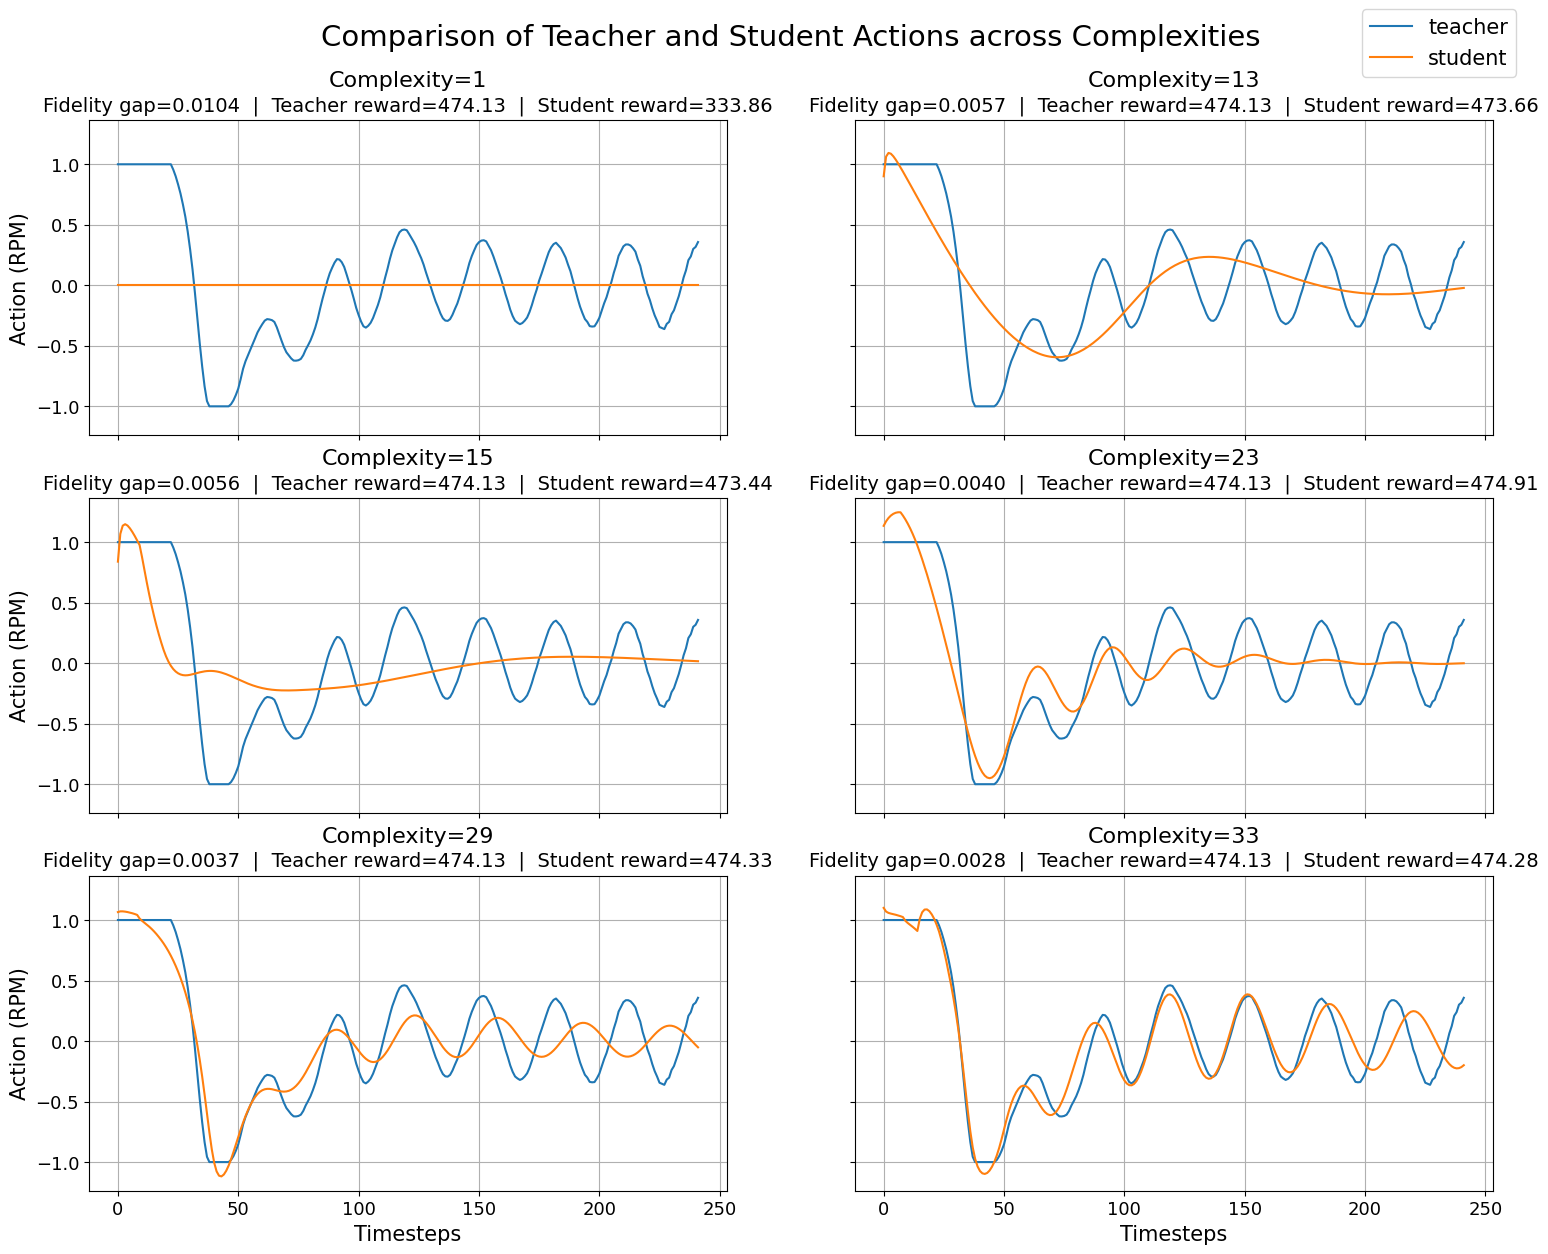

In [11]:
# Plot all as subplots
import math

n_cols = 2
n_rows = math.ceil(len(indeces) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows), sharey=True, sharex=True)
axes = axes.flatten()

for idx, (student_actions, complexity, expression, fidelity) in enumerate(
    zip(all_student_actions, all_complexities, all_expressions, all_fidelities)
):
    ax = axes[idx]
    ax.plot(teacher_actions, label="teacher")
    ax.plot(student_actions, label=f"student")
    ax.legend()
    ax.grid()
    ax.tick_params(axis='both', labelsize=13)
    #ax.set_title(f"Complexity={complexity}\nFidelity gap={fidelity:.4f}  |  Teacher reward={np.sum(teacher_rewards):.2f}  |  Student reward={np.sum(all_rewards[idx]):.2f}", fontsize=11)
    ax.set_title(f"Complexity={complexity}", fontsize=16, y=1.08)
    ax.text(0.5, 1.03,
            f"Fidelity gap={fidelity:.4f}  |  Teacher reward={np.sum(teacher_rewards):.2f}  |  Student reward={np.sum(all_rewards[idx]):.2f}",
            fontsize=14, ha="center", transform=ax.transAxes)

    # Only set x label on bottom row
    if idx >= len(indeces) - n_cols:
        ax.set_xlabel("Timesteps", fontsize=15)
    
    # Only set y label on left column
    if idx % n_cols == 0:
        ax.set_ylabel("Action (RPM)", fontsize=15)

# Hide any unused subplots
for idx in range(len(indeces), len(axes)):
    axes[idx].set_visible(False)

handles, labels = axes[0].get_legend_handles_labels()

# Remove individual legends
for ax in axes[:len(indeces)]:
    ax.get_legend().remove()

# Add single legend for the whole figure
fig.legend(handles, labels, loc="upper right", bbox_to_anchor=(0.96, 1.05), fontsize=15)

plt.tight_layout()
plt.subplots_adjust(wspace=0.2, hspace=0.2)
plt.suptitle(f"Comparison of Teacher and Student Actions across Complexities", fontsize=21, y=1.03)
plt.savefig("comparison_all_complexities.png", bbox_inches='tight')
plt.show()

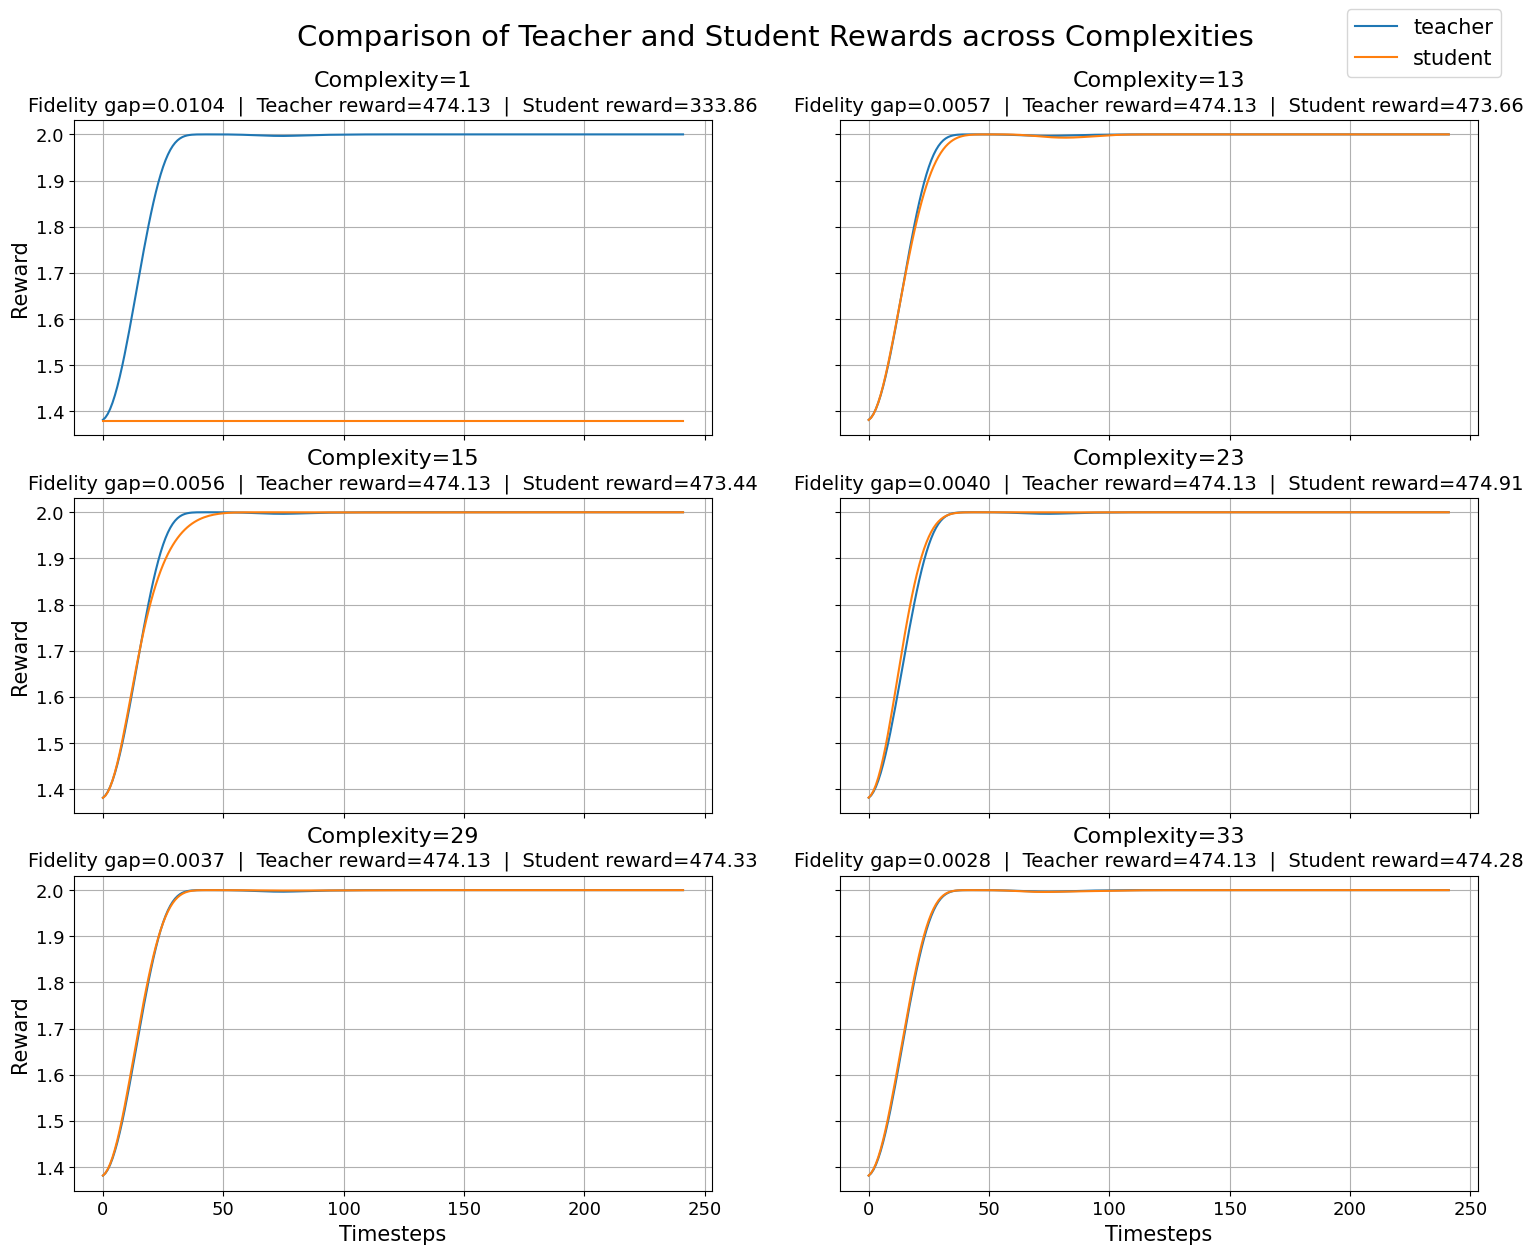

In [12]:
# Reward plots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows), sharey=True, sharex=True)
axes = axes.flatten()

for idx, (student_rewards, complexity, expression, fidelity) in enumerate(
    zip(all_rewards, all_complexities, all_expressions, all_fidelities)
):
    ax = axes[idx]
    ax.plot(teacher_rewards, label="teacher")
    ax.plot(student_rewards, label=f"student")
    ax.legend()
    ax.grid()
    ax.tick_params(axis='both', labelsize=13)
    #ax.set_title(f"Complexity={complexity}\nFidelity gap={fidelity:.4f}  |  Teacher reward={np.sum(teacher_rewards):.2f}  |  Student reward={np.sum(all_rewards[idx]):.2f}", fontsize=11)
    ax.set_title(f"Complexity={complexity}", fontsize=16, y=1.08)
    ax.text(0.5, 1.03,
            f"Fidelity gap={fidelity:.4f}  |  Teacher reward={np.sum(teacher_rewards):.2f}  |  Student reward={np.sum(all_rewards[idx]):.2f}",
            fontsize=14, ha="center", transform=ax.transAxes)

    # Only set x label on bottom row
    if idx >= len(indeces) - n_cols:
        ax.set_xlabel("Timesteps", fontsize=15)
    
    # Only set y label on left column
    if idx % n_cols == 0:
        ax.set_ylabel("Reward", fontsize=15)

# Hide any unused subplots
for idx in range(len(indeces), len(axes)):
    axes[idx].set_visible(False)

handles, labels = axes[0].get_legend_handles_labels()

# Remove individual legends
for ax in axes[:len(indeces)]:
    ax.get_legend().remove()

# Add single legend for the whole figure
fig.legend(handles, labels, loc="upper right", bbox_to_anchor=(0.96, 1.05), fontsize=15)

plt.tight_layout()
plt.subplots_adjust(wspace=0.2, hspace=0.2)
plt.suptitle(f"Comparison of Teacher and Student Rewards across Complexities", fontsize=21, y=1.03)
plt.savefig("comparison_all_complexities_rewards.png", bbox_inches='tight')
plt.show()

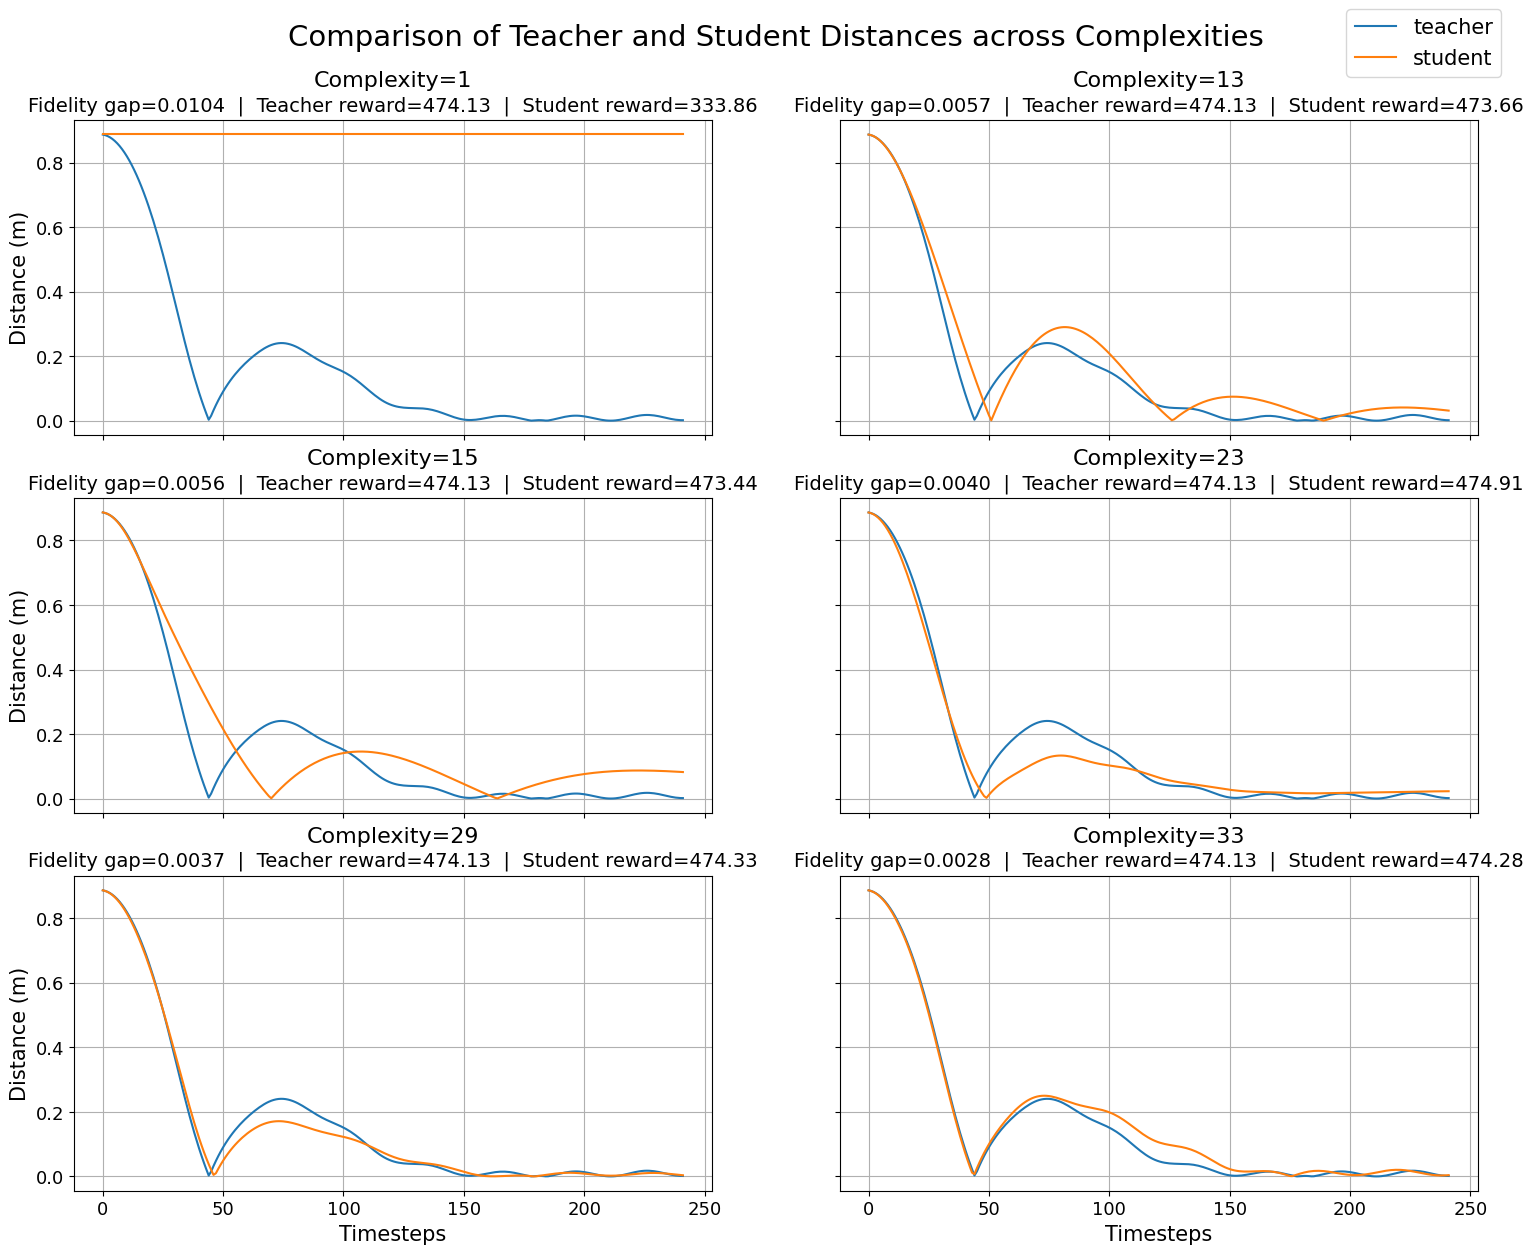

In [13]:
# Distance plot
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows), sharey=True, sharex=True)
axes = axes.flatten()

for idx, (student_distances, complexity, expression, fidelity) in enumerate(
    zip(all_distances, all_complexities, all_expressions, all_fidelities)
):
    ax = axes[idx]
    ax.plot(teacher_distances, label="teacher")
    ax.plot(student_distances, label=f"student")
    ax.legend()
    ax.grid()
    ax.tick_params(axis='both', labelsize=13)
    #ax.set_title(f"Complexity={complexity}\nFidelity gap={fidelity:.4f}  |  Teacher reward={np.sum(teacher_rewards):.2f}  |  Student reward={np.sum(all_rewards[idx]):.2f}", fontsize=11)
    ax.set_title(f"Complexity={complexity}", fontsize=16, y=1.08)
    ax.text(0.5, 1.03,
            f"Fidelity gap={fidelity:.4f}  |  Teacher reward={np.sum(teacher_rewards):.2f}  |  Student reward={np.sum(all_rewards[idx]):.2f}",
            fontsize=14, ha="center", transform=ax.transAxes)

    # Only set x label on bottom row
    if idx >= len(indeces) - n_cols:
        ax.set_xlabel("Timesteps", fontsize=15)
    
    # Only set y label on left column
    if idx % n_cols == 0:
        ax.set_ylabel("Distance (m)", fontsize=15)

# Hide any unused subplots
for idx in range(len(indeces), len(axes)):
    axes[idx].set_visible(False)

handles, labels = axes[0].get_legend_handles_labels()

# Remove individual legends
for ax in axes[:len(indeces)]:
    ax.get_legend().remove()

# Add single legend for the whole figure
fig.legend(handles, labels, loc="upper right", bbox_to_anchor=(0.96, 1.05), fontsize=15)

plt.tight_layout()
plt.subplots_adjust(wspace=0.2, hspace=0.2)
plt.suptitle(f"Comparison of Teacher and Student Distances across Complexities", fontsize=21, y=1.03)
plt.savefig("comparison_all_complexities_distances.png", bbox_inches='tight')
plt.show()


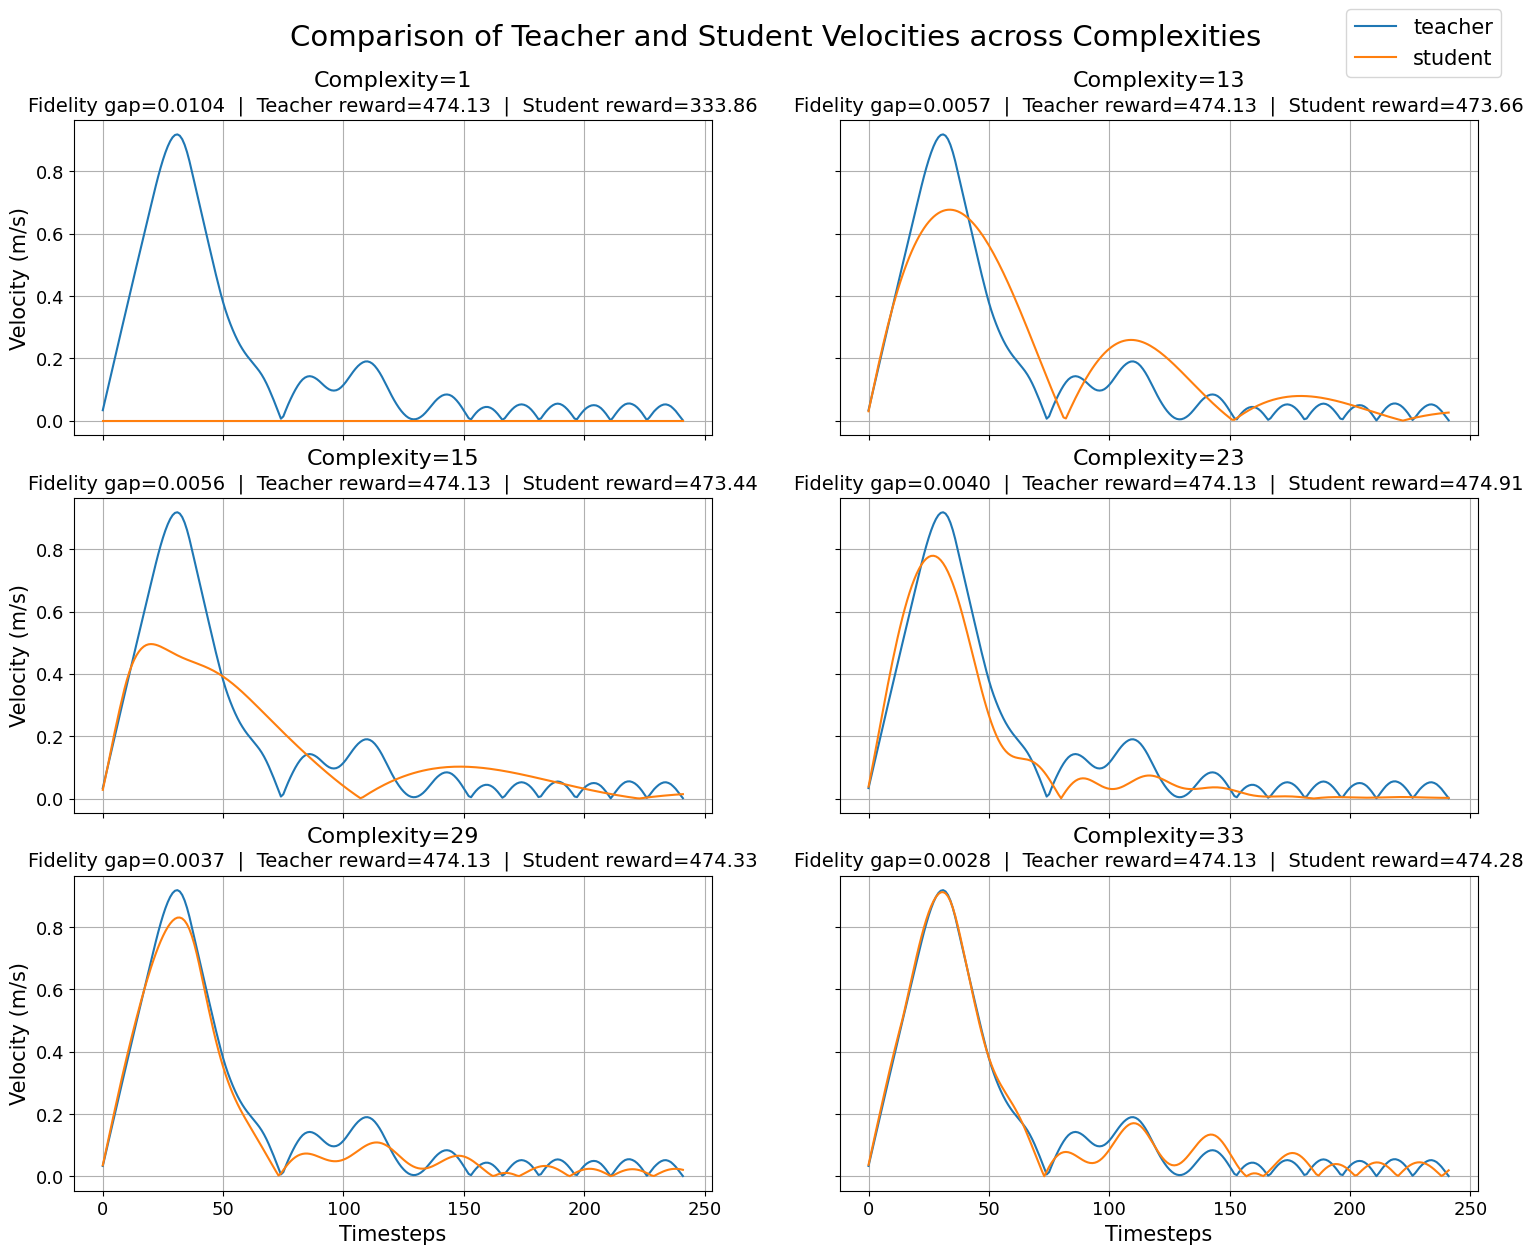

In [14]:
# Velocity plots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows), sharey=True, sharex=True)
axes = axes.flatten()

for idx, (student_velocities, complexity, expression, fidelity) in enumerate(
    zip(all_velocities, all_complexities, all_expressions, all_fidelities)
):
    ax = axes[idx]
    ax.plot(teacher_velocities, label="teacher")
    ax.plot(student_velocities, label=f"student")
    ax.legend()
    ax.grid()
    ax.tick_params(axis='both', labelsize=13)
    #ax.set_title(f"Complexity={complexity}\nFidelity gap={fidelity:.4f}  |  Teacher reward={np.sum(teacher_rewards):.2f}  |  Student reward={np.sum(all_rewards[idx]):.2f}", fontsize=11)
    ax.set_title(f"Complexity={complexity}", fontsize=16, y=1.08)
    ax.text(0.5, 1.03,
            f"Fidelity gap={fidelity:.4f}  |  Teacher reward={np.sum(teacher_rewards):.2f}  |  Student reward={np.sum(all_rewards[idx]):.2f}",
            fontsize=14, ha="center", transform=ax.transAxes)

    # Only set x label on bottom row
    if idx >= len(indeces) - n_cols:
        ax.set_xlabel("Timesteps", fontsize=15)
    
    # Only set y label on left column
    if idx % n_cols == 0:
        ax.set_ylabel("Velocity (m/s)", fontsize=15)

# Hide any unused subplots
for idx in range(len(indeces), len(axes)):
    axes[idx].set_visible(False)

handles, labels = axes[0].get_legend_handles_labels()

# Remove individual legends
for ax in axes[:len(indeces)]:
    ax.get_legend().remove()

# Add single legend for the whole figure
fig.legend(handles, labels, loc="upper right", bbox_to_anchor=(0.96, 1.05), fontsize=15)

plt.tight_layout()
plt.subplots_adjust(wspace=0.2, hspace=0.2)
plt.suptitle(f"Comparison of Teacher and Student Velocities across Complexities", fontsize=21, y=1.03)
plt.savefig("comparison_all_complexities_velocities.png", bbox_inches='tight')
plt.show()

# Maxsize increase --> complexity increase

In [17]:
from io import StringIO

student_paths = {
    # "maxsize_10": r"/home/sofelving/GGSpeciale/GGSpeciale/quadcopter-suite/distil_repeat_nounary/timesteps_5000_maxsize10/best_student_policy.joblib",
    "maxsize=10": r"/home/sofelving/GGSpeciale/GGSpeciale/quadcopter-suite/distil_new/timesteps_5000_maxsize10_3/best_student_policy.joblib",
    "maxsize=20": r"/home/sofelving/GGSpeciale/GGSpeciale/quadcopter-suite/distil/timesteps_5000_maxsize20/best_student_policy.joblib",
    "maxsize=30": r"/home/sofelving/GGSpeciale/GGSpeciale/quadcopter-suite/distil/timesteps_5000_maxsize30/best_student_policy.joblib",
    "maxsize=40": r"/home/sofelving/GGSpeciale/GGSpeciale/quadcopter-suite/distil/timesteps_5000_maxsize40/best_student_policy.joblib",
}


# student_paths_10 = {"max_10_1": r"/home/sofelving/GGSpeciale/GGSpeciale/quadcopter-suite/distil_first_policy/timesteps_5000_maxsize10_1/best_student_policy.joblib",
#                     "max_10_2": r"/home/sofelving/GGSpeciale/GGSpeciale/quadcopter-suite/distil_first_policy/timesteps_5000_maxsize10_2/best_student_policy.joblib",
#                     "max_10_3": r"/home/sofelving/GGSpeciale/GGSpeciale/quadcopter-suite/distil_first_policy/timesteps_5000_maxsize10_3/best_student_policy.joblib",
#                     "max_10_4": r"/home/sofelving/GGSpeciale/GGSpeciale/quadcopter-suite/distil_first_policy/timesteps_5000_maxsize10_4/best_student_policy.joblib",
#                     "max_10_5": r"/home/sofelving/GGSpeciale/GGSpeciale/quadcopter-suite/distil_first_policy/timesteps_5000_maxsize10_5/best_student_policy.joblib",
#                     "max_10_6": r"/home/sofelving/GGSpeciale/GGSpeciale/quadcopter-suite/distil_first_policy/timesteps_5000_maxsize10_6/best_student_policy.joblib",
#                     "max_10_7": r"/home/sofelving/GGSpeciale/GGSpeciale/quadcopter-suite/distil_first_policy/timesteps_5000_maxsize10_7/best_student_policy.joblib",
#                     "max_10_8": r"/home/sofelving/GGSpeciale/GGSpeciale/quadcopter-suite/distil_first_policy/timesteps_5000_maxsize10_8/best_student_policy.joblib",
#                     "max_10_9": r"/home/sofelving/GGSpeciale/GGSpeciale/quadcopter-suite/distil_first_policy/timesteps_5000_maxsize10_9/best_student_policy.joblib",
#                     "max_10_10": r"/home/sofelving/GGSpeciale/GGSpeciale/quadcopter-suite/distil_new/timesteps_5000_maxsize10_3/best_student_policy.joblib",
#                     }

# student_paths_20 = {"max_20_1": r"/home/sofelving/GGSpeciale/GGSpeciale/quadcopter-suite/distil_first_policy/timesteps_5000_maxsize20_1/best_student_policy.joblib",
#                     "max_20_2": r"/home/sofelving/GGSpeciale/GGSpeciale/quadcopter-suite/distil_first_policy/timesteps_5000_maxsize20_2/best_student_policy.joblib",
#                     "max_20_3": r"/home/sofelving/GGSpeciale/GGSpeciale/quadcopter-suite/distil_first_policy/timesteps_5000_maxsize20_3/best_student_policy.joblib",
#                     "max_20_4": r"/home/sofelving/GGSpeciale/GGSpeciale/quadcopter-suite/distil_first_policy/timesteps_5000_maxsize20_4/best_student_policy.joblib",
#                     "max_20_5": r"/home/sofelving/GGSpeciale/GGSpeciale/quadcopter-suite/distil_first_policy/timesteps_5000_maxsize20_5/best_student_policy.joblib",
#                     "max_20_6": r"/home/sofelving/GGSpeciale/GGSpeciale/quadcopter-suite/distil_first_policy/timesteps_5000_maxsize20_6/best_student_policy.joblib",
#                     "max_20_7": r"/home/sofelving/GGSpeciale/GGSpeciale/quadcopter-suite/distil_first_policy/timesteps_5000_maxsize20_7/best_student_policy.joblib",
#                     "max_20_8": r"/home/sofelving/GGSpeciale/GGSpeciale/quadcopter-suite/distil_first_policy/timesteps_5000_maxsize20_8/best_student_policy.joblib",
#                     "max_20_9": r"/home/sofelving/GGSpeciale/GGSpeciale/quadcopter-suite/distil_first_policy/timesteps_5000_maxsize20_9/best_student_policy.joblib",
#                     "max_20_10": r"/home/sofelving/GGSpeciale/GGSpeciale/quadcopter-suite/distil/timesteps_5000_maxsize20/best_student_policy.joblib",
#                     }
# student_paths_30 = {"max_30_1": r"/home/sofelving/GGSpeciale/GGSpeciale/quadcopter-suite/distil_first_policy/timesteps_5000_maxsize30_1/best_student_policy.joblib",
#                     "max_30_2": r"/home/sofelving/GGSpeciale/GGSpeciale/quadcopter-suite/distil_first_policy/timesteps_5000_maxsize30_2/best_student_policy.joblib",
#                     "max_30_3": r"/home/sofelving/GGSpeciale/GGSpeciale/quadcopter-suite/distil_first_policy/timesteps_5000_maxsize30_3/best_student_policy.joblib",
#                     "max_30_4": r"/home/sofelving/GGSpeciale/GGSpeciale/quadcopter-suite/distil_first_policy/timesteps_5000_maxsize30_4/best_student_policy.joblib",
#                     "max_30_5": r"/home/sofelving/GGSpeciale/GGSpeciale/quadcopter-suite/distil_first_policy/timesteps_5000_maxsize30_5/best_student_policy.joblib",
#                     "max_30_6": r"/home/sofelving/GGSpeciale/GGSpeciale/quadcopter-suite/distil_first_policy/timesteps_5000_maxsize30_6/best_student_policy.joblib",
#                     "max_30_7": r"/home/sofelving/GGSpeciale/GGSpeciale/quadcopter-suite/distil_first_policy/timesteps_5000_maxsize30_7/best_student_policy.joblib",
#                     "max_30_8": r"/home/sofelving/GGSpeciale/GGSpeciale/quadcopter-suite/distil_first_policy/timesteps_5000_maxsize30_8/best_student_policy.joblib",
#                     "max_30_9": r"/home/sofelving/GGSpeciale/GGSpeciale/quadcopter-suite/distil_first_policy/timesteps_5000_maxsize30_9/best_student_policy.joblib",
#                     "max_30_10": r"/home/sofelving/GGSpeciale/GGSpeciale/quadcopter-suite/distil/timesteps_5000_maxsize30/best_student_policy.joblib",
#                     }
# student_paths_40 = {"max_40_1": r"/home/sofelving/GGSpeciale/GGSpeciale/quadcopter-suite/distil_first_policy/timesteps_5000_maxsize40_1/best_student_policy.joblib",
#                     "max_40_2": r"/home/sofelving/GGSpeciale/GGSpeciale/quadcopter-suite/distil_first_policy/timesteps_5000_maxsize40_2/best_student_policy.joblib",
#                     "max_40_3": r"/home/sofelving/GGSpeciale/GGSpeciale/quadcopter-suite/distil_first_policy/timesteps_5000_maxsize40_3/best_student_policy.joblib",
#                     "max_40_4": r"/home/sofelving/GGSpeciale/GGSpeciale/quadcopter-suite/distil_first_policy/timesteps_5000_maxsize40_4/best_student_policy.joblib",
#                     "max_40_5": r"/home/sofelving/GGSpeciale/GGSpeciale/quadcopter-suite/distil_first_policy/timesteps_5000_maxsize40_5/best_student_policy.joblib",
#                     "max_40_6": r"/home/sofelving/GGSpeciale/GGSpeciale/quadcopter-suite/distil_first_policy/timesteps_5000_maxsize40_6/best_student_policy.joblib",
#                     "max_40_7": r"/home/sofelving/GGSpeciale/GGSpeciale/quadcopter-suite/distil_first_policy/timesteps_5000_maxsize40_7/best_student_policy.joblib",
#                     "max_40_8": r"/home/sofelving/GGSpeciale/GGSpeciale/quadcopter-suite/distil_first_policy/timesteps_5000_maxsize40_8/best_student_policy.joblib",
#                     "max_40_9": r"/home/sofelving/GGSpeciale/GGSpeciale/quadcopter-suite/distil_first_policy/timesteps_5000_maxsize40_9/best_student_policy.joblib",
#                     "max_40_10": r"/home/sofelving/GGSpeciale/GGSpeciale/quadcopter-suite/distil/timesteps_5000_maxsize40/best_student_policy.joblib",
#                     }

# student_paths = {**student_paths_10, **student_paths_20, **student_paths_30, **student_paths_40}

teacher = PPO.load(r"/home/sofelving/GGSpeciale/GGSpeciale/quadcopter-suite/results/save-04.10.2026_15.39.13/best_model.zip")

teacher_rewards, teacher_actions, teacher_obs = collect_actions(teacher, seed=42)
teacher_obs_flat   = teacher_obs.reshape(len(teacher_obs), -1)
teacher_distances  = np.linalg.norm(teacher_obs_flat[:, 0:3] - TARGET_POS, axis=1)
teacher_velocities = np.linalg.norm(teacher_obs_flat[:, 6:9], axis=1)

# indices = [0, 6, 7, 11, 14, 15]

all_results = {}

for name, policy_path in student_paths.items():
    print(f"\nProcessing: {name}")

    base_policy = PySRPolicy.load(policy_path)
    n_expressions = len(base_policy.policy_list[0].sr.equations_)

    all_student_actions  = []
    all_complexities     = []
    all_expressions      = []
    all_fidelities       = []
    all_rewards          = []
    all_distances        = []
    all_velocities       = []
    all_performance_gaps = []

    for idx in range(n_expressions):
        stdout, stderr = sys.stdout, sys.stderr
        try:
            sys.stdout = sys.stderr = StringIO()
            student = PySRPolicy.load_policy_at_index(policy_path, idx)
        finally:
            sys.stdout, sys.stderr = stdout, stderr

        complexity      = base_policy.policy_list[0].sr.equations_.iloc[idx]["complexity"]
        expression      = base_policy.policy_list[0].sr.equations_.iloc[idx]["equation"]
        fidelity        = base_policy.policy_list[0].sr.equations_.iloc[idx]["fidelity_loss"]
        performance_gap = base_policy.policy_list[0].sr.equations_.iloc[idx]["perf_gap"]

        student_rewards, student_actions, student_obs = collect_actions(student, seed=42)

        student_obs_flat   = student_obs.reshape(len(student_obs), -1)
        student_distances  = np.linalg.norm(student_obs_flat[:, 0:3] - TARGET_POS, axis=1)
        student_velocities = np.linalg.norm(student_obs_flat[:, 6:9], axis=1)

        all_student_actions.append(student_actions)
        all_complexities.append(complexity)
        all_expressions.append(expression)
        all_fidelities.append(fidelity)
        all_rewards.append(student_rewards)
        all_distances.append(student_distances)
        all_velocities.append(student_velocities)
        all_performance_gaps.append(performance_gap)

        print(f"  Finished idx {idx} (complexity {complexity})")

    all_results[name] = {
        "base_policy":        base_policy,
        "student_actions":    all_student_actions,
        "complexities":       all_complexities,
        "expressions":        all_expressions,
        "fidelities":         all_fidelities,
        "rewards":            all_rewards,
        "distances":          all_distances,
        "velocities":         all_velocities,
        "performance_gaps":   all_performance_gaps,
    }

print("\nDone collecting all results")

[INFO] BaseAviary.__init__() loaded parameters from the drone's .urdf:
[INFO] m 0.027000, L 0.039700,
[INFO] ixx 0.000014, iyy 0.000014, izz 0.000022,
[INFO] kf 3.160000e-10, km 7.940000e-12,
[INFO] t2w 2.250000, max_speed_kmh 30.000000,
[INFO] gnd_eff_coeff 11.368590, prop_radius 0.023135,
[INFO] drag_xy_coeff 0.000001, drag_z_coeff 0.000001,
[INFO] dw_coeff_1 2267.180000, dw_coeff_2 0.160000, dw_coeff_3 -0.110000

Processing: maxsize=10
Policy loaded
[INFO] BaseAviary.__init__() loaded parameters from the drone's .urdf:
[INFO] m 0.027000, L 0.039700,
[INFO] ixx 0.000014, iyy 0.000014, izz 0.000022,
[INFO] kf 3.160000e-10, km 7.940000e-12,
[INFO] t2w 2.250000, max_speed_kmh 30.000000,
[INFO] gnd_eff_coeff 11.368590, prop_radius 0.023135,
[INFO] drag_xy_coeff 0.000001, drag_z_coeff 0.000001,
[INFO] dw_coeff_1 2267.180000, dw_coeff_2 0.160000, dw_coeff_3 -0.110000
  Finished idx 0 (complexity 1)
[INFO] BaseAviary.__init__() loaded parameters from the drone's .urdf:
[INFO] m 0.027000, L 

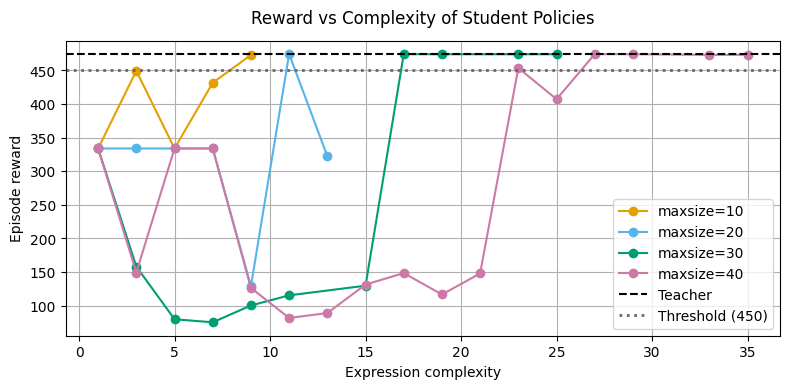

In [18]:
GOOD_REWARD_THRESHOLD = 450

colors = {
    "maxsize=10": "#E69F00",  # orange
    "maxsize=20": "#56B4E9",  # sky blue
    "maxsize=30": "#009E73",  # green
    "maxsize=40": "#CC79A7",  # pink
}
# --- Plot 1: Total reward vs complexity per maxsize ---
fig, ax = plt.subplots(figsize=(8, 4))

for name, data in all_results.items():
    total_rewards = [sum(r) for r in data["rewards"]]
    ax.plot(data["complexities"], total_rewards, marker="o", label=name, color=colors[name])

ax.axhline(sum(teacher_rewards), color="black", linestyle="--", linewidth=1.5, label="Teacher")
ax.axhline(GOOD_REWARD_THRESHOLD, color="dimgrey", linestyle=":", linewidth=2, label=f"Threshold ({GOOD_REWARD_THRESHOLD})")
ax.set_xlabel("Expression complexity")
ax.set_ylabel("Episode reward")
ax.set_title("Reward vs Complexity of Student Policies", y=1.03)
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.savefig("reward_vs_complexity_maxsize.png", dpi=150)
plt.show()


── maxsize=10 ──
Policy loaded
[INFO] BaseAviary.__init__() loaded parameters from the drone's .urdf:
[INFO] m 0.027000, L 0.039700,
[INFO] ixx 0.000014, iyy 0.000014, izz 0.000022,
[INFO] kf 3.160000e-10, km 7.940000e-12,
[INFO] t2w 2.250000, max_speed_kmh 30.000000,
[INFO] gnd_eff_coeff 11.368590, prop_radius 0.023135,
[INFO] drag_xy_coeff 0.000001, drag_z_coeff 0.000001,
[INFO] dw_coeff_1 2267.180000, dw_coeff_2 0.160000, dw_coeff_3 -0.110000
[INFO] BaseAviary.__init__() loaded parameters from the drone's .urdf:
[INFO] m 0.027000, L 0.039700,
[INFO] ixx 0.000014, iyy 0.000014, izz 0.000022,
[INFO] kf 3.160000e-10, km 7.940000e-12,
[INFO] t2w 2.250000, max_speed_kmh 30.000000,
[INFO] gnd_eff_coeff 11.368590, prop_radius 0.023135,
[INFO] drag_xy_coeff 0.000001, drag_z_coeff 0.000001,
[INFO] dw_coeff_1 2267.180000, dw_coeff_2 0.160000, dw_coeff_3 -0.110000
[INFO] BaseAviary.__init__() loaded parameters from the drone's .urdf:
[INFO] m 0.027000, L 0.039700,
[INFO] ixx 0.000014, iyy 0.0

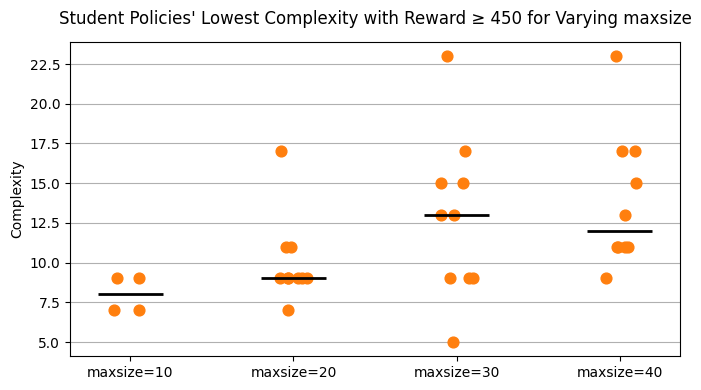

In [16]:
from io import StringIO

THRESHOLD = 450

groups = {
    "maxsize=10": student_paths_10,
    "maxsize=20": student_paths_20,
    "maxsize=30": student_paths_30,
    "maxsize=40": student_paths_40,
}


first_working = {label: [] for label in groups}

for group_label, paths in groups.items():
    print(f"\n── {group_label} ──")
    for run_name, policy_path in paths.items():
        base_policy = PySRPolicy.load(policy_path)
        n_expr = len(base_policy.policy_list[0].sr.equations_)

        found = None
        for idx in range(n_expr):
            stdout, stderr = sys.stdout, sys.stderr
            try:
                sys.stdout = sys.stderr = StringIO()
                student = PySRPolicy.load_policy_at_index(policy_path, idx)
            finally:
                sys.stdout, sys.stderr = stdout, stderr

            complexity = base_policy.policy_list[0].sr.equations_.iloc[idx]["complexity"]
            rewards, _, _ = collect_actions(student, seed=42)
            total = sum(rewards)

            if total >= THRESHOLD:
                found = int(complexity)
                break  # stop at first working

        first_working[group_label].append(found)
        print(f"  {run_name}: first working complexity = {found} "
              f"({'none' if found is None else ''})")

# Plot
fig, ax = plt.subplots(figsize=(7, 4))

group_labels = list(first_working.keys())
x_positions  = np.arange(len(group_labels))

for x, label in zip(x_positions, group_labels):
    values  = first_working[label]
    numeric = [v for v in values if v is not None]
    none_count = values.count(None)

    # jitter x slightly so points don't overlap
    jitter = np.random.uniform(-0.1, 0.1, size=len(numeric))
    ax.scatter(x + jitter, numeric, color="tab:orange", zorder=3,
               s=60, label="run" if x == 0 else "")

    if numeric:
        ax.hlines(np.median(numeric), x - 0.2, x + 0.2,
                  color="black", linewidth=2, zorder=4)


ax.set_xticks(x_positions)
ax.set_xticklabels(group_labels)
ax.set_ylabel("Complexity")
ax.set_title(f"Student Policies' Lowest Complexity with Reward ≥ {THRESHOLD} for Varying maxsize", y=1.03)
ax.grid(True, axis="y")
plt.tight_layout()
plt.savefig("first_working_complexity_by_maxsize.png", dpi=150)
plt.show()

# Variance

In [ ]:
from io import StringIO

student_paths = {
    "student 1": r"/home/sofelving/GGSpeciale/GGSpeciale/quadcopter-suite/distil_repeat_nounary/timesteps_20000_maxsize30_1/best_student_policy.joblib",
    "student 2": r"/home/sofelving/GGSpeciale/GGSpeciale/quadcopter-suite/distil_repeat_nounary/timesteps_20000_maxsize30_2/best_student_policy.joblib",
    "student 3": r"/home/sofelving/GGSpeciale/GGSpeciale/quadcopter-suite/distil_repeat_nounary/timesteps_20000_maxsize30_3/best_student_policy.joblib",
    "student 4": r"/home/sofelving/GGSpeciale/GGSpeciale/quadcopter-suite/distil_repeat_nounary/timesteps_20000_maxsize30_4/best_student_policy.joblib",
    "student 5": r"/home/sofelving/GGSpeciale/GGSpeciale/quadcopter-suite/distil_repeat_nounary/timesteps_20000_maxsize30_5/best_student_policy.joblib",
}

teacher = PPO.load(r"/home/sofelving/GGSpeciale/GGSpeciale/quadcopter-suite/results/save-04.10.2026_15.39.13/best_model.zip")

teacher_rewards, teacher_actions, teacher_obs = collect_actions(teacher, seed=42)
teacher_obs_flat   = teacher_obs.reshape(len(teacher_obs), -1)
teacher_distances  = np.linalg.norm(teacher_obs_flat[:, 0:3] - TARGET_POS, axis=1)
teacher_velocities = np.linalg.norm(teacher_obs_flat[:, 6:9], axis=1)

indices = [6, 7, 10, 11]

all_results = {}

for name, policy_path in student_paths.items():
    print(f"\nProcessing: {name}")

    base_policy = PySRPolicy.load(policy_path)
    n_expressions = len(base_policy.policy_list[0].sr.equations_)

    all_student_actions  = []
    all_complexities     = []
    all_expressions      = []
    all_fidelities       = []
    all_rewards          = []
    all_distances        = []
    all_velocities       = []
    all_performance_gaps = []

    for idx in range(n_expressions):
        stdout, stderr = sys.stdout, sys.stderr
        try:
            sys.stdout = sys.stderr = StringIO()
            student = PySRPolicy.load_policy_at_index(policy_path, idx)
        finally:
            sys.stdout, sys.stderr = stdout, stderr

        complexity      = base_policy.policy_list[0].sr.equations_.iloc[idx]["complexity"]
        expression      = base_policy.policy_list[0].sr.equations_.iloc[idx]["equation"]
        fidelity        = base_policy.policy_list[0].sr.equations_.iloc[idx]["fidelity_loss"]
        performance_gap = base_policy.policy_list[0].sr.equations_.iloc[idx]["perf_gap"]

        student_rewards, student_actions, student_obs = collect_actions(student, seed=42)

        student_obs_flat   = student_obs.reshape(len(student_obs), -1)
        student_distances  = np.linalg.norm(student_obs_flat[:, 0:3] - TARGET_POS, axis=1)
        student_velocities = np.linalg.norm(student_obs_flat[:, 6:9], axis=1)

        all_student_actions.append(student_actions)
        all_complexities.append(complexity)
        all_expressions.append(expression)
        all_fidelities.append(fidelity)
        all_rewards.append(student_rewards)
        all_distances.append(student_distances)
        all_velocities.append(student_velocities)
        all_performance_gaps.append(performance_gap)

        print(f"  Finished idx {idx} (complexity {complexity})")

    all_results[name] = {
        "base_policy":        base_policy,
        "student_actions":    all_student_actions,
        "complexities":       all_complexities,
        "expressions":        all_expressions,
        "fidelities":         all_fidelities,
        "rewards":            all_rewards,
        "distances":          all_distances,
        "velocities":         all_velocities,
        "performance_gaps":   all_performance_gaps,
    }

print("\nDone collecting all results")

[INFO] BaseAviary.__init__() loaded parameters from the drone's .urdf:
[INFO] m 0.027000, L 0.039700,
[INFO] ixx 0.000014, iyy 0.000014, izz 0.000022,
[INFO] kf 3.160000e-10, km 7.940000e-12,
[INFO] t2w 2.250000, max_speed_kmh 30.000000,
[INFO] gnd_eff_coeff 11.368590, prop_radius 0.023135,
[INFO] drag_xy_coeff 0.000001, drag_z_coeff 0.000001,
[INFO] dw_coeff_1 2267.180000, dw_coeff_2 0.160000, dw_coeff_3 -0.110000

Processing: student 1
Policy loaded
[INFO] BaseAviary.__init__() loaded parameters from the drone's .urdf:
[INFO] m 0.027000, L 0.039700,
[INFO] ixx 0.000014, iyy 0.000014, izz 0.000022,
[INFO] kf 3.160000e-10, km 7.940000e-12,
[INFO] t2w 2.250000, max_speed_kmh 30.000000,
[INFO] gnd_eff_coeff 11.368590, prop_radius 0.023135,
[INFO] drag_xy_coeff 0.000001, drag_z_coeff 0.000001,
[INFO] dw_coeff_1 2267.180000, dw_coeff_2 0.160000, dw_coeff_3 -0.110000
  Finished idx 0 (complexity 1)
[INFO] BaseAviary.__init__() loaded parameters from the drone's .urdf:
[INFO] m 0.027000, L 0

In [35]:
first_data = next(iter(all_results.values()))
selected_complexities = [first_data["complexities"][i] for i in indices]

all_complexities_set = sorted(set(selected_complexities))

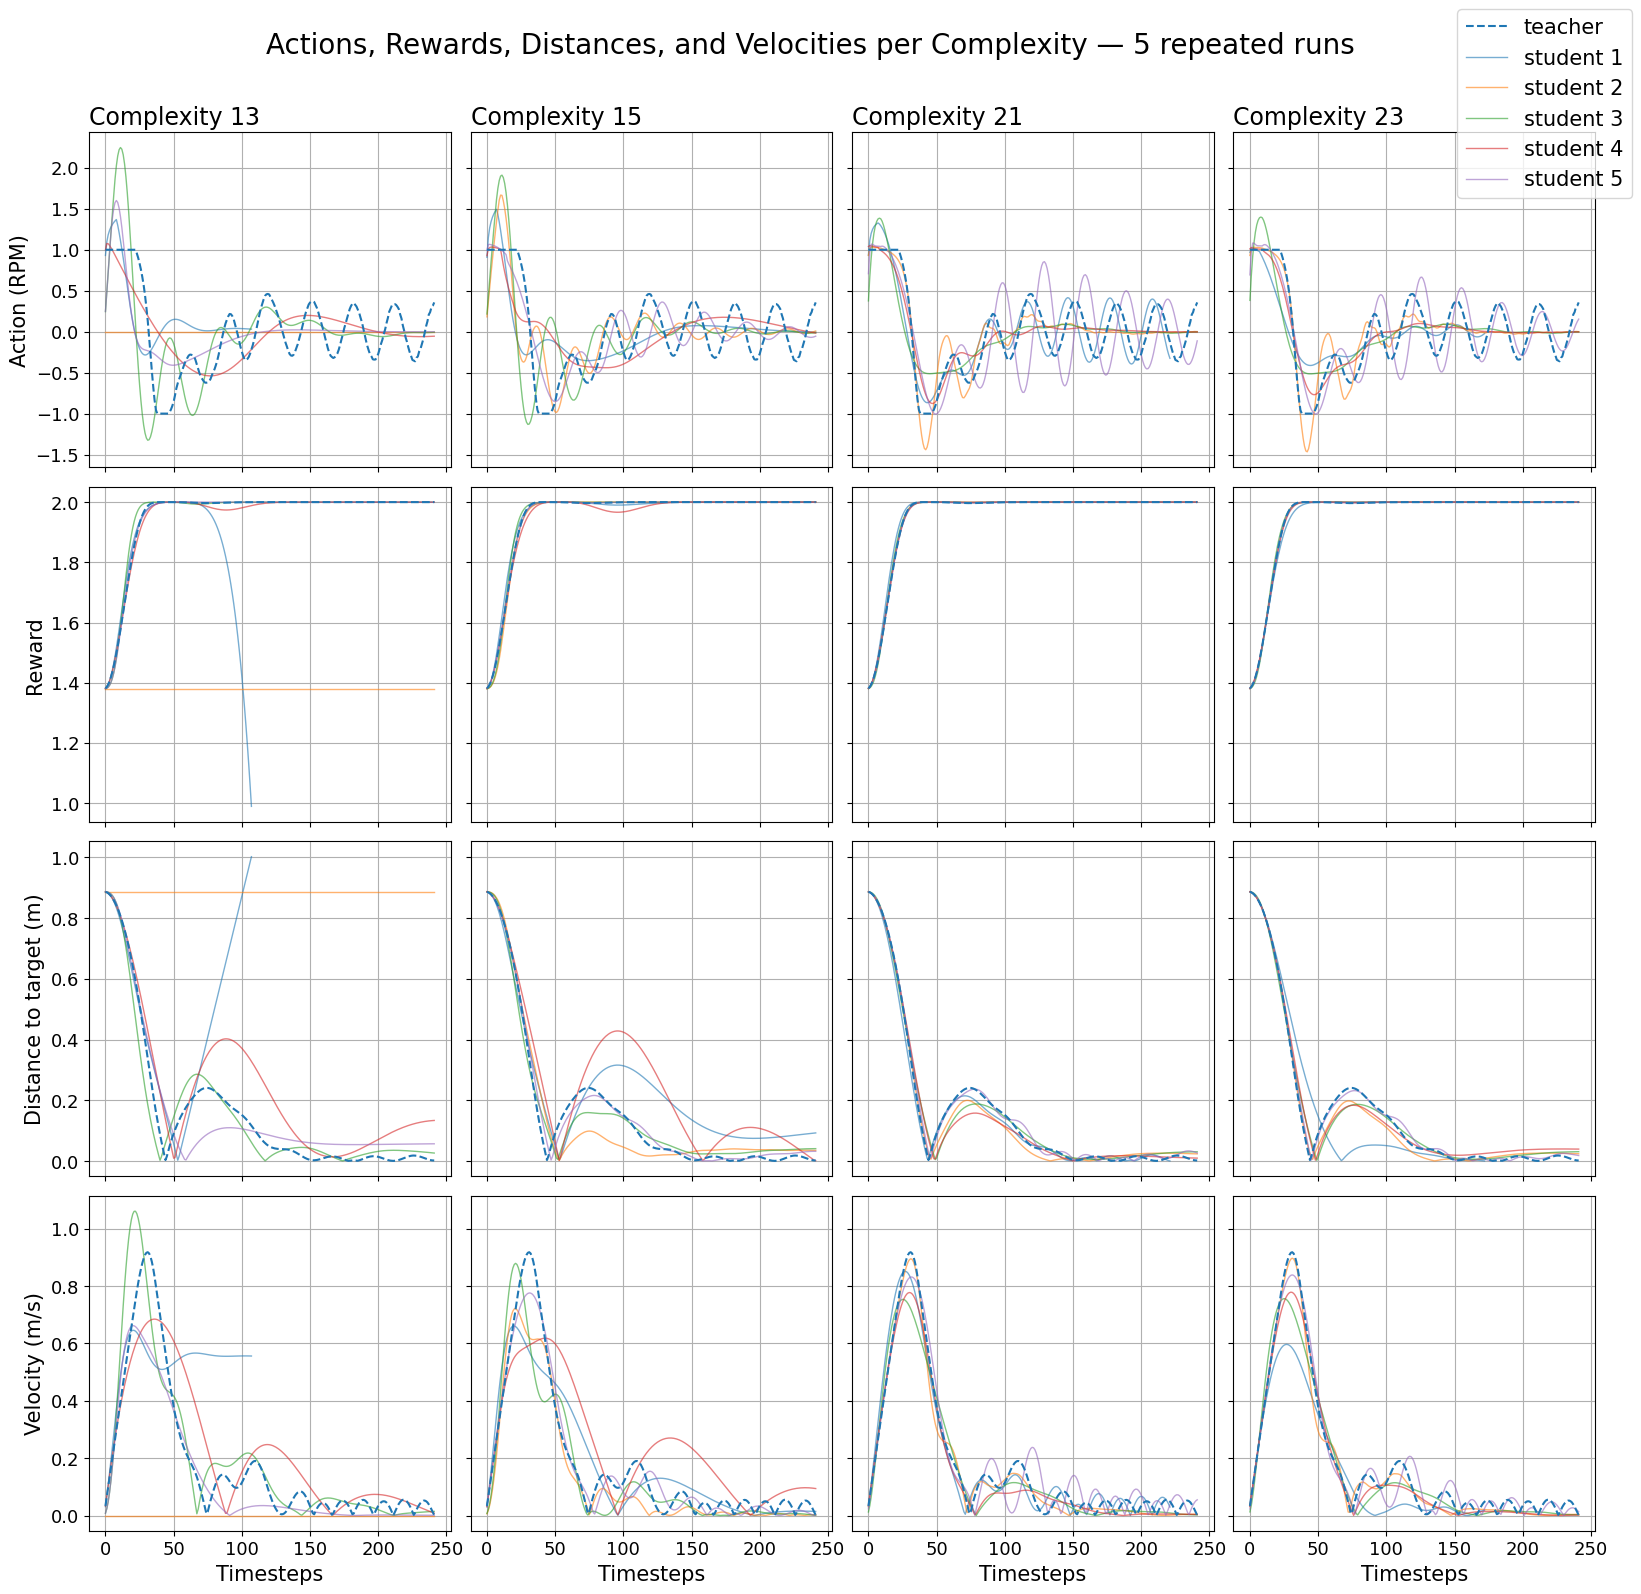

In [43]:
import math

n_metric_rows = 4  # actions, distances, rewards
n_cols = len(all_complexities_set)

fig, axes = plt.subplots(n_metric_rows, n_cols, figsize=(4 * n_cols, 4 * n_metric_rows), 
                          sharey='row', sharex='col')

colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

for col_idx, complexity in enumerate(all_complexities_set):

    ax_action = axes[0, col_idx]
    ax_reward = axes[1, col_idx]
    ax_dist   = axes[2, col_idx]
    ax_velocity = axes[3, col_idx]

    # Teacher
    ax_action.plot(teacher_actions, color="tab:blue", linestyle="--", linewidth=1.5,
                   label="teacher", zorder=5)
    ax_dist.plot(teacher_distances, color="tab:blue", linestyle="--", linewidth=1.5,
                 label="teacher", zorder=5)
    ax_reward.plot(teacher_rewards, color="tab:blue", linestyle="--", linewidth=1.5,
                   label="teacher", zorder=5)
    ax_velocity.plot(teacher_velocities, color="tab:blue", linestyle="--", linewidth=1.5,
                     label="teacher", zorder=5)

    # Each run
    for run_idx, (name, data) in enumerate(all_results.items()):
        if complexity not in data["complexities"]:
            continue
        expr_idx = data["complexities"].index(complexity)

        ax_action.plot(data["student_actions"][expr_idx],
                       color=colors[run_idx % len(colors)], alpha=0.6, linewidth=1, label=name)
        ax_reward.plot(data["rewards"][expr_idx],
                       color=colors[run_idx % len(colors)], alpha=0.6, linewidth=1, label=name)
        ax_dist.plot(data["distances"][expr_idx],
                     color=colors[run_idx % len(colors)], alpha=0.6, linewidth=1, label=name)
        ax_velocity.plot(data["velocities"][expr_idx],
                       color=colors[run_idx % len(colors)], alpha=0.6, linewidth=1, label=name)

    ax_action.set_title(f"Complexity {complexity}", fontsize=17, loc="left")
    ax_action.grid(True)
    ax_dist.grid(True)
    ax_reward.grid(True)
    ax_velocity.grid(True)
    for ax in [ax_action, ax_reward, ax_dist, ax_velocity]:
        ax.tick_params(axis='both', labelsize=13)
    ax_velocity.set_xlabel("Timesteps", fontsize=15)

    if col_idx == 0:
        ax_action.set_ylabel("Action (RPM)", fontsize=15)
        ax_dist.set_ylabel("Distance to target (m)", fontsize=15)
        ax_reward.set_ylabel("Reward", fontsize=15)
        ax_velocity.set_ylabel("Velocity (m/s)", fontsize=15)

# Single shared legend
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right", bbox_to_anchor=(1.02, 1), fontsize=15)

plt.suptitle("Actions, Rewards, Distances, and Velocities per Complexity — 5 repeated runs", fontsize=20)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig("variance_per_complexity.png", dpi=150, bbox_inches='tight')
plt.show()

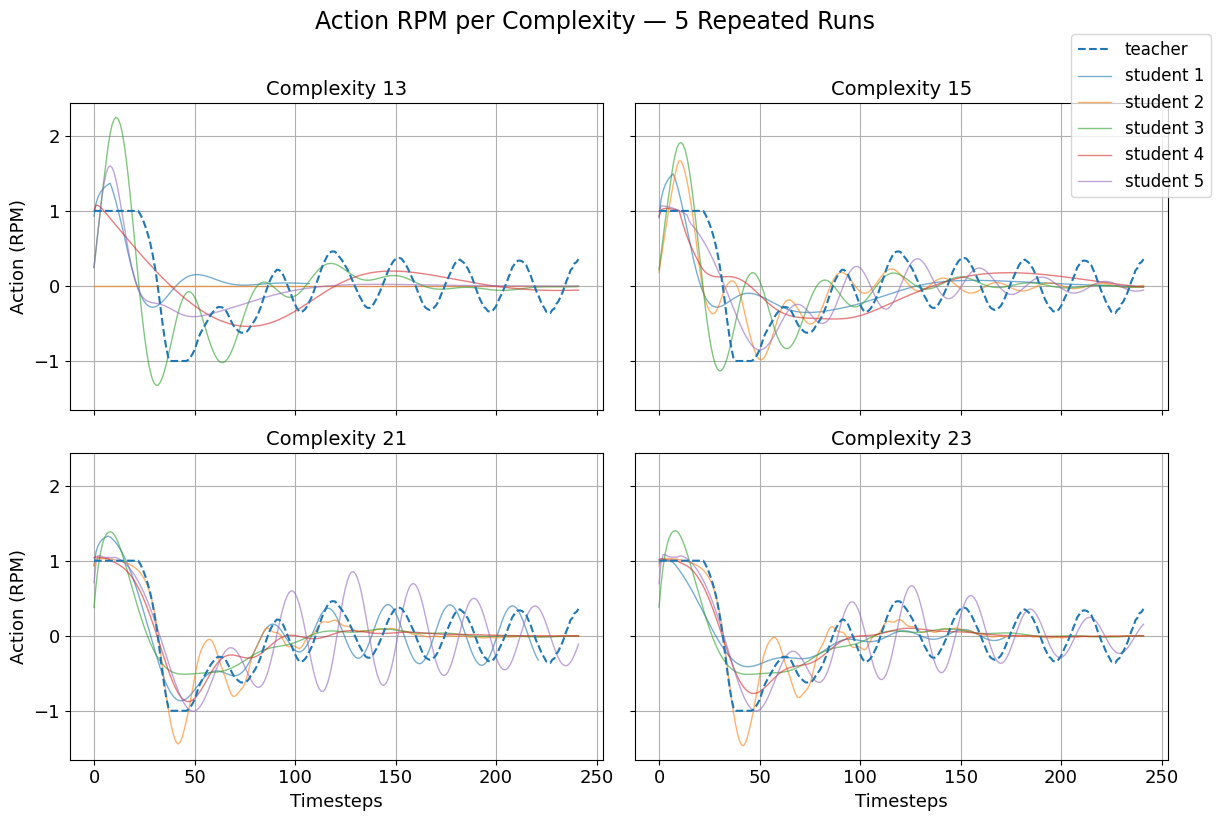

In [ ]:
# Pick which 4 complexities to show
complexities_to_plot = list(all_complexities_set)

n = len(complexities_to_plot)
n_cols = 2
n_rows = math.ceil(n / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows), sharey=True, sharex=True)
axes = axes.flatten()
axes = axes.flatten()
colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

for ax_idx, complexity in enumerate(complexities_to_plot):
    ax = axes[ax_idx]

    ax.plot(teacher_actions, color="tab:blue", linestyle="--",
            linewidth=1.5, label="teacher", zorder=5)

    for run_idx, (name, data) in enumerate(all_results.items()):
        if complexity not in data["complexities"]:
            continue
        expr_idx = data["complexities"].index(complexity)
        ax.plot(data["student_actions"][expr_idx],
                color=colors[run_idx % len(colors)],
                alpha=0.6, linewidth=1, label=name)

    ax.set_title(f"Complexity {complexity}", loc="center", fontsize=14)
    ax.grid(True)
    ax.tick_params(axis='both', labelsize=13)
    if ax_idx in [0, 2]:
        ax.set_ylabel("Action (RPM)", fontsize=13)
    if ax_idx in [2, 3]:
        ax.set_xlabel("Timesteps", fontsize=13)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right",
           bbox_to_anchor=(1.02, 1), fontsize=12)

plt.suptitle("Action RPM per Complexity — 5 Repeated Runs", fontsize=17, y=1.02)
plt.tight_layout()
plt.savefig("actions_2x2.png", dpi=150, bbox_inches="tight")
plt.show()


## Single student

In [ ]:
from io import StringIO

policy_path = r"/home/sofelving/GGSpeciale/GGSpeciale/quadcopter-suite/distil/timesteps_5000_maxsize20/best_student_policy.joblib"

teacher = PPO.load(r"/home/sofelving/GGSpeciale/GGSpeciale/quadcopter-suite/results/save-04.10.2026_15.39.13/best_model.zip")

base_policy = PySRPolicy.load(policy_path)
n_expressions = len(base_policy.policy_list[0].sr.equations_)

teacher_rewards, teacher_actions, teacher_obs = collect_actions(teacher, seed=42)
teacher_obs_flat  = teacher_obs.reshape(len(teacher_obs), -1)
teacher_distances = np.linalg.norm(teacher_obs_flat[:, 0:3] - TARGET_POS, axis=1)
teacher_velocities = np.linalg.norm(teacher_obs_flat[:, 6:9], axis=1)

indeces = [5]

all_student_actions    = []
all_complexities       = []
all_expressions        = []
all_fidelities         = []
all_rewards            = []
all_distances          = []
all_velocities         = []
all_performance_gaps   = []

for idx in indeces:
    stdout, stderr = sys.stdout, sys.stderr
    try:
        sys.stdout = sys.stderr = StringIO()
        student = PySRPolicy.load_policy_at_index(policy_path, idx)
    finally:
        sys.stdout, sys.stderr = stdout, stderr
    
    complexity = base_policy.policy_list[0].sr.equations_.iloc[idx]["complexity"]
    expression = base_policy.policy_list[0].sr.equations_.iloc[idx]["equation"]
    fidelity   = base_policy.policy_list[0].sr.equations_.iloc[idx]["fidelity_loss"]
    performance_gap = base_policy.policy_list[0].sr.equations_.iloc[idx]["perf_gap"]

    student_rewards, student_actions, student_obs = collect_actions(student, seed=42)

    student_obs_flat   = student_obs.reshape(len(student_obs), -1)
    student_distances  = np.linalg.norm(student_obs_flat[:, 0:3] - TARGET_POS, axis=1)
    student_velocities = np.linalg.norm(student_obs_flat[:, 6:9], axis=1)

    all_student_actions.append(student_actions)
    all_complexities.append(complexity)
    all_expressions.append(expression)
    all_fidelities.append(fidelity)
    all_rewards.append(student_rewards)
    all_distances.append(student_distances)
    all_velocities.append(student_velocities)
    all_performance_gaps.append(performance_gap)
    print(f"Finished for {idx}")


Policy loaded
[INFO] BaseAviary.__init__() loaded parameters from the drone's .urdf:
[INFO] m 0.027000, L 0.039700,
[INFO] ixx 0.000014, iyy 0.000014, izz 0.000022,
[INFO] kf 3.160000e-10, km 7.940000e-12,
[INFO] t2w 2.250000, max_speed_kmh 30.000000,
[INFO] gnd_eff_coeff 11.368590, prop_radius 0.023135,
[INFO] drag_xy_coeff 0.000001, drag_z_coeff 0.000001,
[INFO] dw_coeff_1 2267.180000, dw_coeff_2 0.160000, dw_coeff_3 -0.110000
[INFO] BaseAviary.__init__() loaded parameters from the drone's .urdf:
[INFO] m 0.027000, L 0.039700,
[INFO] ixx 0.000014, iyy 0.000014, izz 0.000022,
[INFO] kf 3.160000e-10, km 7.940000e-12,
[INFO] t2w 2.250000, max_speed_kmh 30.000000,
[INFO] gnd_eff_coeff 11.368590, prop_radius 0.023135,
[INFO] drag_xy_coeff 0.000001, drag_z_coeff 0.000001,
[INFO] dw_coeff_1 2267.180000, dw_coeff_2 0.160000, dw_coeff_3 -0.110000
[INFO] BaseAviary.__init__() loaded parameters from the drone's .urdf:
[INFO] m 0.027000, L 0.039700,
[INFO] ixx 0.000014, iyy 0.000014, izz 0.00002

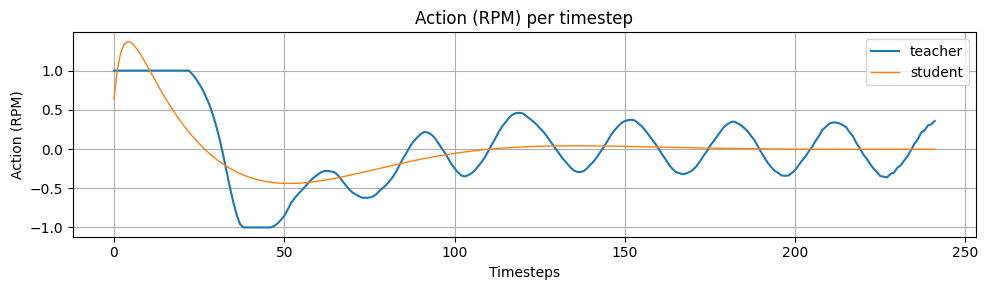

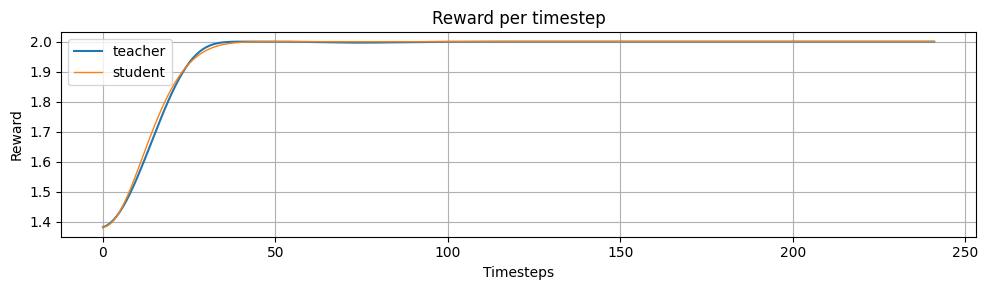

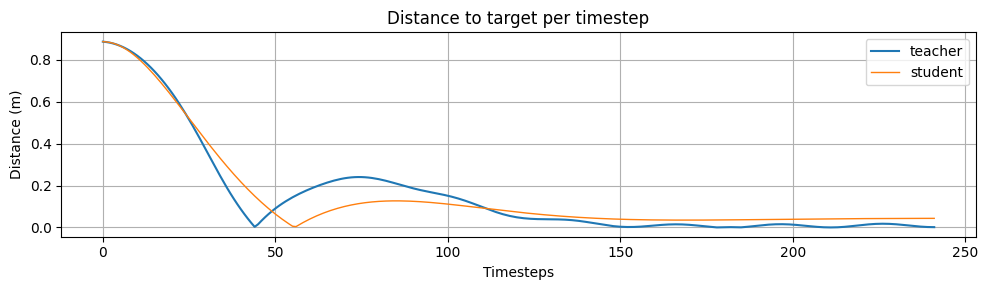

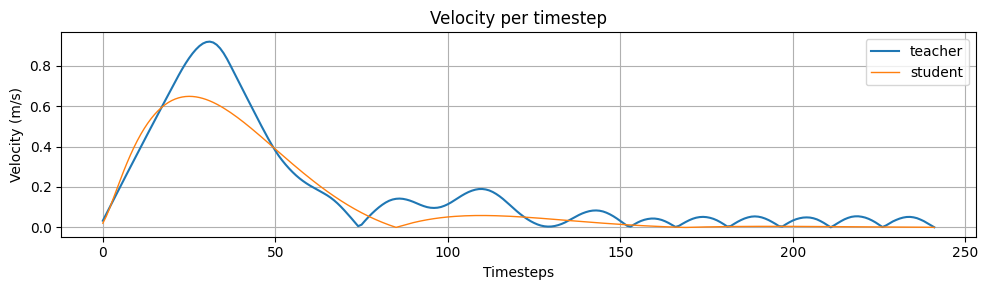

In [124]:
for idx in range(len(indeces)):
    complexity     = all_complexities[idx]
    fidelity       = all_fidelities[idx]
    expression     = all_expressions[idx]
    student_reward = np.sum(all_rewards[idx])
    teacher_reward = np.sum(teacher_rewards)

    # Action
    fig, ax = plt.subplots(figsize=(10, 3))
    ax.plot(teacher_actions, color="tab:blue", linewidth=1.5, label="teacher")
    ax.plot(all_student_actions[idx], color="tab:orange", linewidth=1, label="student")
    ax.set_ylabel("Action (RPM)")
    ax.set_xlabel("Timesteps")
    ax.set_title("Action (RPM) per timestep")
    ax.legend()
    ax.grid(True)
    plt.tight_layout()
    plt.savefig(f"pd_action.png", dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()

    # Reward
    fig, ax = plt.subplots(figsize=(10, 3))
    ax.plot(teacher_rewards, color="tab:blue", linewidth=1.5, label="teacher")
    ax.plot(all_rewards[idx], color="tab:orange", linewidth=1, label="student")
    ax.set_ylabel("Reward")
    ax.set_xlabel("Timesteps")
    ax.set_title("Reward per timestep")
    ax.legend()
    ax.grid(True)
    plt.tight_layout()
    plt.savefig(f"pd_reward.png", dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()

    # Distance
    fig, ax = plt.subplots(figsize=(10, 3))
    ax.plot(teacher_distances, color="tab:blue", linewidth=1.5, label="teacher")
    ax.plot(all_distances[idx], color="tab:orange", linewidth=1, label="student")
    ax.set_ylabel("Distance (m)")
    ax.set_xlabel("Timesteps")
    ax.set_title("Distance to target per timestep")
    ax.legend()
    ax.grid(True)
    plt.tight_layout()
    plt.savefig(f"pd_distance.png", dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()

    # Velocity
    fig, ax = plt.subplots(figsize=(10, 3))
    ax.plot(teacher_velocities, color="tab:blue", linewidth=1.5, label="teacher")
    ax.plot(all_velocities[idx], color="tab:orange", linewidth=1, label="student")
    ax.set_ylabel("Velocity (m/s)")
    ax.set_xlabel("Timesteps")
    ax.set_title("Velocity per timestep")
    ax.legend()
    ax.grid(True)
    plt.tight_layout()
    plt.savefig(f"pd_velocity.png", dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()

In [116]:
all_expressions[idx]

'((x26 + ((x2 * -1.0993544) - x8)) * 0.6204503) + 0.71136916'

## Reward function

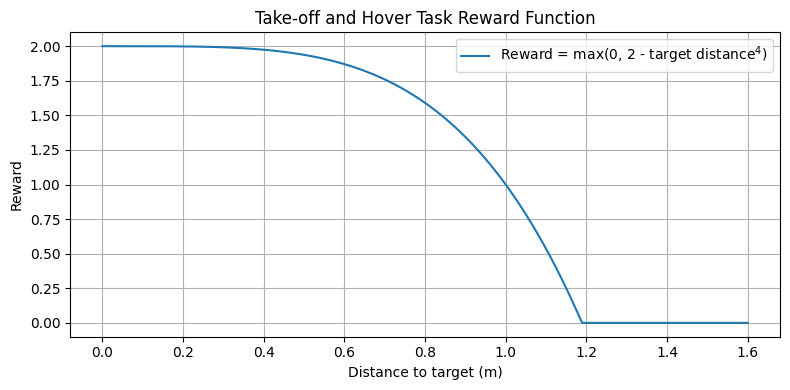

In [131]:
import numpy as np
import matplotlib.pyplot as plt

distances = np.linspace(0, 1.6, 500)
rewards = np.maximum(0, 2 - distances**4)

plt.figure(figsize=(8, 4))
plt.plot(distances, rewards)
plt.xlabel("Distance to target (m)")
plt.ylabel("Reward")
plt.title("Take-off and Hover Task Reward Function")
plt.legend(["Reward = max(0, 2 - target distance$^4$)"])
plt.grid()
plt.tight_layout()
plt.savefig("reward_function.png", bbox_inches='tight')
plt.show()

## Varying timesteps

In [ ]:
from io import StringIO

student_paths_1250 = {
    "timesteps1250_1": r"/home/sofelving/GGSpeciale/GGSpeciale/quadcopter-suite/distil_timesteps_maxsize20/timesteps_1250_maxsize20_1/best_student_policy.joblib",
    "timesteps1250_2": r"/home/sofelving/GGSpeciale/GGSpeciale/quadcopter-suite/distil_timesteps_maxsize20/timesteps_1250_maxsize20_2/best_student_policy.joblib",
    "timesteps1250_3": r"/home/sofelving/GGSpeciale/GGSpeciale/quadcopter-suite/distil_timesteps_maxsize20/timesteps_1250_maxsize20_3/best_student_policy.joblib",
    "timesteps1250_4": r"/home/sofelving/GGSpeciale/GGSpeciale/quadcopter-suite/distil_timesteps_maxsize20/timesteps_1250_maxsize20_4/best_student_policy.joblib",
    "timesteps1250_5": r"/home/sofelving/GGSpeciale/GGSpeciale/quadcopter-suite/distil_timesteps_maxsize20/timesteps_1250_maxsize20_5/best_student_policy.joblib",
    "timesteps1250_6": r"/home/sofelving/GGSpeciale/GGSpeciale/quadcopter-suite/distil_timesteps_maxsize20/timesteps_1250_maxsize20_6/best_student_policy.joblib",
    "timesteps1250_7": r"/home/sofelving/GGSpeciale/GGSpeciale/quadcopter-suite/distil_timesteps_maxsize20/timesteps_1250_maxsize20_7/best_student_policy.joblib",
    "timesteps1250_8": r"/home/sofelving/GGSpeciale/GGSpeciale/quadcopter-suite/distil_timesteps_maxsize20/timesteps_1250_maxsize20_8/best_student_policy.joblib",
    "timesteps1250_9": r"/home/sofelving/GGSpeciale/GGSpeciale/quadcopter-suite/distil_timesteps_maxsize20/timesteps_1250_maxsize20_9/best_student_policy.joblib",
    "timesteps1250_10": r"/home/sofelving/GGSpeciale/GGSpeciale/quadcopter-suite/distil_timesteps_maxsize20/timesteps_1250_maxsize20_10/best_student_policy.joblib",
}

student_paths_2500 = {
    "timesteps2500_1": r"/home/sofelving/GGSpeciale/GGSpeciale/quadcopter-suite/distil_timesteps_maxsize20/timesteps_2500_maxsize20_1/best_student_policy.joblib",
    "timesteps2500_2": r"/home/sofelving/GGSpeciale/GGSpeciale/quadcopter-suite/distil_timesteps_maxsize20/timesteps_2500_maxsize20_2/best_student_policy.joblib",
    "timesteps2500_3": r"/home/sofelving/GGSpeciale/GGSpeciale/quadcopter-suite/distil_timesteps_maxsize20/timesteps_2500_maxsize20_3/best_student_policy.joblib",
    "timesteps2500_4": r"/home/sofelving/GGSpeciale/GGSpeciale/quadcopter-suite/distil_timesteps_maxsize20/timesteps_2500_maxsize20_4/best_student_policy.joblib",
    "timesteps2500_5": r"/home/sofelving/GGSpeciale/GGSpeciale/quadcopter-suite/distil_timesteps_maxsize20/timesteps_2500_maxsize20_5/best_student_policy.joblib",
    "timesteps2500_6": r"/home/sofelving/GGSpeciale/GGSpeciale/quadcopter-suite/distil_timesteps_maxsize20/timesteps_2500_maxsize20_6/best_student_policy.joblib",
    "timesteps2500_7": r"/home/sofelving/GGSpeciale/GGSpeciale/quadcopter-suite/distil_timesteps_maxsize20/timesteps_2500_maxsize20_7/best_student_policy.joblib",
    "timesteps2500_8": r"/home/sofelving/GGSpeciale/GGSpeciale/quadcopter-suite/distil_timesteps_maxsize20/timesteps_2500_maxsize20_8/best_student_policy.joblib",
    "timesteps2500_9": r"/home/sofelving/GGSpeciale/GGSpeciale/quadcopter-suite/distil_timesteps_maxsize20/timesteps_2500_maxsize20_9/best_student_policy.joblib",
    "timesteps2500_10": r"/home/sofelving/GGSpeciale/GGSpeciale/quadcopter-suite/distil_timesteps_maxsize20/timesteps_2500_maxsize20_10/best_student_policy.joblib",
}

student_paths_5000 = {
    "timesteps5000_1": r"/home/sofelving/GGSpeciale/GGSpeciale/quadcopter-suite/distil_timesteps_maxsize20/timesteps_5000_maxsize20_1/best_student_policy.joblib",
    "timesteps5000_2": r"/home/sofelving/GGSpeciale/GGSpeciale/quadcopter-suite/distil_timesteps_maxsize20/timesteps_5000_maxsize20_2/best_student_policy.joblib",
    "timesteps5000_3": r"/home/sofelving/GGSpeciale/GGSpeciale/quadcopter-suite/distil_timesteps_maxsize20/timesteps_5000_maxsize20_3/best_student_policy.joblib",
    "timesteps5000_4": r"/home/sofelving/GGSpeciale/GGSpeciale/quadcopter-suite/distil_timesteps_maxsize20/timesteps_5000_maxsize20_4/best_student_policy.joblib",
    "timesteps5000_5": r"/home/sofelving/GGSpeciale/GGSpeciale/quadcopter-suite/distil_timesteps_maxsize20/timesteps_5000_maxsize20_5/best_student_policy.joblib",
    "timesteps5000_6": r"/home/sofelving/GGSpeciale/GGSpeciale/quadcopter-suite/distil_timesteps_maxsize20/timesteps_5000_maxsize20_6/best_student_policy.joblib",
    "timesteps5000_7": r"/home/sofelving/GGSpeciale/GGSpeciale/quadcopter-suite/distil_timesteps_maxsize20/timesteps_5000_maxsize20_7/best_student_policy.joblib",
    "timesteps5000_8": r"/home/sofelving/GGSpeciale/GGSpeciale/quadcopter-suite/distil_timesteps_maxsize20/timesteps_5000_maxsize20_8/best_student_policy.joblib",
    "timesteps5000_9": r"/home/sofelving/GGSpeciale/GGSpeciale/quadcopter-suite/distil_timesteps_maxsize20/timesteps_5000_maxsize20_9/best_student_policy.joblib",
    "timesteps5000_10": r"/home/sofelving/GGSpeciale/GGSpeciale/quadcopter-suite/distil_timesteps_maxsize20/timesteps_5000_maxsize20_10/best_student_policy.joblib",
}

student_paths_10000 = {
    "timesteps10000_1": r"/home/sofelving/GGSpeciale/GGSpeciale/quadcopter-suite/distil_timesteps_maxsize20/timesteps_10000_maxsize20_1/best_student_policy.joblib",
    "timesteps10000_2": r"/home/sofelving/GGSpeciale/GGSpeciale/quadcopter-suite/distil_timesteps_maxsize20/timesteps_10000_maxsize20_2/best_student_policy.joblib",
    "timesteps10000_3": r"/home/sofelving/GGSpeciale/GGSpeciale/quadcopter-suite/distil_timesteps_maxsize20/timesteps_10000_maxsize20_3/best_student_policy.joblib",
    "timesteps10000_4": r"/home/sofelving/GGSpeciale/GGSpeciale/quadcopter-suite/distil_timesteps_maxsize20/timesteps_10000_maxsize20_4/best_student_policy.joblib",
    "timesteps10000_5": r"/home/sofelving/GGSpeciale/GGSpeciale/quadcopter-suite/distil_timesteps_maxsize20/timesteps_10000_maxsize20_5/best_student_policy.joblib",
    "timesteps10000_6": r"/home/sofelving/GGSpeciale/GGSpeciale/quadcopter-suite/distil_timesteps_maxsize20/timesteps_10000_maxsize20_6/best_student_policy.joblib",
    "timesteps10000_7": r"/home/sofelving/GGSpeciale/GGSpeciale/quadcopter-suite/distil_timesteps_maxsize20/timesteps_10000_maxsize20_7/best_student_policy.joblib",
    "timesteps10000_8": r"/home/sofelving/GGSpeciale/GGSpeciale/quadcopter-suite/distil_timesteps_maxsize20/timesteps_10000_maxsize20_8/best_student_policy.joblib",
    "timesteps10000_9": r"/home/sofelving/GGSpeciale/GGSpeciale/quadcopter-suite/distil_timesteps_maxsize20/timesteps_10000_maxsize20_9/best_student_policy.joblib",
    "timesteps10000_10": r"/home/sofelving/GGSpeciale/GGSpeciale/quadcopter-suite/distil_timesteps_maxsize20/timesteps_10000_maxsize20_10/best_student_policy.joblib",
}

student_paths_20000 = {
    "timesteps20000_1": r"/home/sofelving/GGSpeciale/GGSpeciale/quadcopter-suite/distil_timesteps_maxsize20/timesteps_20000_maxsize20_1/best_student_policy.joblib",
    "timesteps20000_2": r"/home/sofelving/GGSpeciale/GGSpeciale/quadcopter-suite/distil_timesteps_maxsize20/timesteps_20000_maxsize20_2/best_student_policy.joblib",
    "timesteps20000_3": r"/home/sofelving/GGSpeciale/GGSpeciale/quadcopter-suite/distil_timesteps_maxsize20/timesteps_20000_maxsize20_3/best_student_policy.joblib",
    "timesteps20000_4": r"/home/sofelving/GGSpeciale/GGSpeciale/quadcopter-suite/distil_timesteps_maxsize20/timesteps_20000_maxsize20_4/best_student_policy.joblib",
    "timesteps20000_5": r"/home/sofelving/GGSpeciale/GGSpeciale/quadcopter-suite/distil_timesteps_maxsize20/timesteps_20000_maxsize20_5/best_student_policy.joblib",
    "timesteps20000_6": r"/home/sofelving/GGSpeciale/GGSpeciale/quadcopter-suite/distil_timesteps_maxsize20/timesteps_20000_maxsize20_6/best_student_policy.joblib",
    "timesteps20000_7": r"/home/sofelving/GGSpeciale/GGSpeciale/quadcopter-suite/distil_timesteps_maxsize20/timesteps_20000_maxsize20_7/best_student_policy.joblib",
    "timesteps20000_8": r"/home/sofelving/GGSpeciale/GGSpeciale/quadcopter-suite/distil_timesteps_maxsize20/timesteps_20000_maxsize20_8/best_student_policy.joblib",
    "timesteps20000_9": r"/home/sofelving/GGSpeciale/GGSpeciale/quadcopter-suite/distil_timesteps_maxsize20/timesteps_20000_maxsize20_9/best_student_policy.joblib",
    "timesteps20000_10": r"/home/sofelving/GGSpeciale/GGSpeciale/quadcopter-suite/distil_timesteps_maxsize20/timesteps_20000_maxsize20_10/best_student_policy.joblib",
}

student_paths_1200 = {
    "timesteps1200_1": r"/home/sofelving/GGSpeciale/GGSpeciale/quadcopter-suite/distil_timesteps_24_maxsize20/timesteps_1200_maxsize20_1/best_student_policy.joblib",
    "timesteps1200_2": r"/home/sofelving/GGSpeciale/GGSpeciale/quadcopter-suite/distil_timesteps_24_maxsize20/timesteps_1200_maxsize20_2/best_student_policy.joblib",
    "timesteps1200_3": r"/home/sofelving/GGSpeciale/GGSpeciale/quadcopter-suite/distil_timesteps_24_maxsize20/timesteps_1200_maxsize20_3/best_student_policy.joblib",
    "timesteps1200_4": r"/home/sofelving/GGSpeciale/GGSpeciale/quadcopter-suite/distil_timesteps_24_maxsize20/timesteps_1200_maxsize20_4/best_student_policy.joblib",
    "timesteps1200_5": r"/home/sofelving/GGSpeciale/GGSpeciale/quadcopter-suite/distil_timesteps_24_maxsize20/timesteps_1200_maxsize20_5/best_student_policy.joblib",
    "timesteps1200_6": r"/home/sofelving/GGSpeciale/GGSpeciale/quadcopter-suite/distil_timesteps_24_maxsize20/timesteps_1200_maxsize20_6/best_student_policy.joblib",
    "timesteps1200_7": r"/home/sofelving/GGSpeciale/GGSpeciale/quadcopter-suite/distil_timesteps_24_maxsize20/timesteps_1200_maxsize20_7/best_student_policy.joblib",
    "timesteps1200_8": r"/home/sofelving/GGSpeciale/GGSpeciale/quadcopter-suite/distil_timesteps_24_maxsize20/timesteps_1200_maxsize20_8/best_student_policy.joblib",
    "timesteps1200_9": r"/home/sofelving/GGSpeciale/GGSpeciale/quadcopter-suite/distil_timesteps_24_maxsize20/timesteps_1200_maxsize20_9/best_student_policy.joblib",
    "timesteps1200_10": r"/home/sofelving/GGSpeciale/GGSpeciale/quadcopter-suite/distil_timesteps_24_maxsize20/timesteps_1200_maxsize20_10/best_student_policy.joblib",
}

student_paths_2400 = {
    "timesteps2400_1": r"/home/sofelving/GGSpeciale/GGSpeciale/quadcopter-suite/distil_timesteps_24_maxsize20/timesteps_2400_maxsize20_1/best_student_policy.joblib",
    "timesteps2400_2": r"/home/sofelving/GGSpeciale/GGSpeciale/quadcopter-suite/distil_timesteps_24_maxsize20/timesteps_2400_maxsize20_2/best_student_policy.joblib",
    "timesteps2400_3": r"/home/sofelving/GGSpeciale/GGSpeciale/quadcopter-suite/distil_timesteps_24_maxsize20/timesteps_2400_maxsize20_3/best_student_policy.joblib",
    "timesteps2400_4": r"/home/sofelving/GGSpeciale/GGSpeciale/quadcopter-suite/distil_timesteps_24_maxsize20/timesteps_2400_maxsize20_4/best_student_policy.joblib",
    "timesteps2400_5": r"/home/sofelving/GGSpeciale/GGSpeciale/quadcopter-suite/distil_timesteps_24_maxsize20/timesteps_2400_maxsize20_5/best_student_policy.joblib",
    "timesteps2400_6": r"/home/sofelving/GGSpeciale/GGSpeciale/quadcopter-suite/distil_timesteps_24_maxsize20/timesteps_2400_maxsize20_6/best_student_policy.joblib",
    "timesteps2400_7": r"/home/sofelving/GGSpeciale/GGSpeciale/quadcopter-suite/distil_timesteps_24_maxsize20/timesteps_2400_maxsize20_7/best_student_policy.joblib",
    "timesteps2400_8": r"/home/sofelving/GGSpeciale/GGSpeciale/quadcopter-suite/distil_timesteps_24_maxsize20/timesteps_2400_maxsize20_8/best_student_policy.joblib",
    "timesteps2400_9": r"/home/sofelving/GGSpeciale/GGSpeciale/quadcopter-suite/distil_timesteps_24_maxsize20/timesteps_2400_maxsize20_9/best_student_policy.joblib",
    "timesteps2400_10": r"/home/sofelving/GGSpeciale/GGSpeciale/quadcopter-suite/distil_timesteps_24_maxsize20/timesteps_2400_maxsize20_10/best_student_policy.joblib",
}

student_paths_4800 = {
    "timesteps4800_1": r"/home/sofelving/GGSpeciale/GGSpeciale/quadcopter-suite/distil_timesteps_24_maxsize20/timesteps_4800_maxsize20_1/best_student_policy.joblib",
    "timesteps4800_2": r"/home/sofelving/GGSpeciale/GGSpeciale/quadcopter-suite/distil_timesteps_24_maxsize20/timesteps_4800_maxsize20_2/best_student_policy.joblib",
    "timesteps4800_3": r"/home/sofelving/GGSpeciale/GGSpeciale/quadcopter-suite/distil_timesteps_24_maxsize20/timesteps_4800_maxsize20_3/best_student_policy.joblib",
    "timesteps4800_4": r"/home/sofelving/GGSpeciale/GGSpeciale/quadcopter-suite/distil_timesteps_24_maxsize20/timesteps_4800_maxsize20_4/best_student_policy.joblib",
    "timesteps4800_5": r"/home/sofelving/GGSpeciale/GGSpeciale/quadcopter-suite/distil_timesteps_24_maxsize20/timesteps_4800_maxsize20_5/best_student_policy.joblib",
    "timesteps4800_6": r"/home/sofelving/GGSpeciale/GGSpeciale/quadcopter-suite/distil_timesteps_24_maxsize20/timesteps_4800_maxsize20_6/best_student_policy.joblib",
    "timesteps4800_7": r"/home/sofelving/GGSpeciale/GGSpeciale/quadcopter-suite/distil_timesteps_24_maxsize20/timesteps_4800_maxsize20_7/best_student_policy.joblib",
    "timesteps4800_8": r"/home/sofelving/GGSpeciale/GGSpeciale/quadcopter-suite/distil_timesteps_24_maxsize20/timesteps_4800_maxsize20_8/best_student_policy.joblib",
    "timesteps4800_9": r"/home/sofelving/GGSpeciale/GGSpeciale/quadcopter-suite/distil_timesteps_24_maxsize20/timesteps_4800_maxsize20_9/best_student_policy.joblib",
    "timesteps4800_10": r"/home/sofelving/GGSpeciale/GGSpeciale/quadcopter-suite/distil_timesteps_24_maxsize20/timesteps_4800_maxsize20_10/best_student_policy.joblib",
}

student_paths_9600 = {
    "timesteps9600_1": r"/home/sofelving/GGSpeciale/GGSpeciale/quadcopter-suite/distil_timesteps_24_maxsize20/timesteps_9600_maxsize20_1/best_student_policy.joblib",
    "timesteps9600_2": r"/home/sofelving/GGSpeciale/GGSpeciale/quadcopter-suite/distil_timesteps_24_maxsize20/timesteps_9600_maxsize20_2/best_student_policy.joblib",
    "timesteps9600_3": r"/home/sofelving/GGSpeciale/GGSpeciale/quadcopter-suite/distil_timesteps_24_maxsize20/timesteps_9600_maxsize20_3/best_student_policy.joblib",
    "timesteps9600_4": r"/home/sofelving/GGSpeciale/GGSpeciale/quadcopter-suite/distil_timesteps_24_maxsize20/timesteps_9600_maxsize20_4/best_student_policy.joblib",
    "timesteps9600_5": r"/home/sofelving/GGSpeciale/GGSpeciale/quadcopter-suite/distil_timesteps_24_maxsize20/timesteps_9600_maxsize20_5/best_student_policy.joblib",
    "timesteps9600_6": r"/home/sofelving/GGSpeciale/GGSpeciale/quadcopter-suite/distil_timesteps_24_maxsize20/timesteps_9600_maxsize20_6/best_student_policy.joblib",
    "timesteps9600_7": r"/home/sofelving/GGSpeciale/GGSpeciale/quadcopter-suite/distil_timesteps_24_maxsize20/timesteps_9600_maxsize20_7/best_student_policy.joblib",
    "timesteps9600_8": r"/home/sofelving/GGSpeciale/GGSpeciale/quadcopter-suite/distil_timesteps_24_maxsize20/timesteps_9600_maxsize20_8/best_student_policy.joblib",
    "timesteps9600_9": r"/home/sofelving/GGSpeciale/GGSpeciale/quadcopter-suite/distil_timesteps_24_maxsize20/timesteps_9600_maxsize20_9/best_student_policy.joblib",
    "timesteps9600_10": r"/home/sofelving/GGSpeciale/GGSpeciale/quadcopter-suite/distil_timesteps_24_maxsize20/timesteps_9600_maxsize20_10/best_student_policy.joblib",
}

student_paths_19200 = {
    "timesteps19200_1": r"/home/sofelving/GGSpeciale/GGSpeciale/quadcopter-suite/distil_timesteps_24_maxsize20/timesteps_19200_maxsize20_1/best_student_policy.joblib",
    "timesteps19200_2": r"/home/sofelving/GGSpeciale/GGSpeciale/quadcopter-suite/distil_timesteps_24_maxsize20/timesteps_19200_maxsize20_2/best_student_policy.joblib",
    "timesteps19200_3": r"/home/sofelving/GGSpeciale/GGSpeciale/quadcopter-suite/distil_timesteps_24_maxsize20/timesteps_19200_maxsize20_3/best_student_policy.joblib",
    "timesteps19200_4": r"/home/sofelving/GGSpeciale/GGSpeciale/quadcopter-suite/distil_timesteps_24_maxsize20/timesteps_19200_maxsize20_4/best_student_policy.joblib",
    "timesteps19200_5": r"/home/sofelving/GGSpeciale/GGSpeciale/quadcopter-suite/distil_timesteps_24_maxsize20/timesteps_19200_maxsize20_5/best_student_policy.joblib",
    "timesteps19200_6": r"/home/sofelving/GGSpeciale/GGSpeciale/quadcopter-suite/distil_timesteps_24_maxsize20/timesteps_19200_maxsize20_6/best_student_policy.joblib",
    "timesteps19200_7": r"/home/sofelving/GGSpeciale/GGSpeciale/quadcopter-suite/distil_timesteps_24_maxsize20/timesteps_19200_maxsize20_7/best_student_policy.joblib",
    "timesteps19200_8": r"/home/sofelving/GGSpeciale/GGSpeciale/quadcopter-suite/distil_timesteps_24_maxsize20/timesteps_19200_maxsize20_8/best_student_policy.joblib",
    "timesteps19200_9": r"/home/sofelving/GGSpeciale/GGSpeciale/quadcopter-suite/distil_timesteps_24_maxsize20/timesteps_19200_maxsize20_9/best_student_policy.joblib",
    "timesteps19200_10": r"/home/sofelving/GGSpeciale/GGSpeciale/quadcopter-suite/distil_timesteps_24_maxsize20/timesteps_19200_maxsize20_10/best_student_policy.joblib",
}

student_paths = {
    **student_paths_1250,
    **student_paths_2500,
    **student_paths_5000,
    **student_paths_10000,
    **student_paths_20000,
    **student_paths_1200,
    **student_paths_2400,
    **student_paths_4800,
    **student_paths_9600,
    **student_paths_19200,
    }

teacher = PPO.load(r"/home/sofelving/GGSpeciale/GGSpeciale/quadcopter-suite/results/save-04.10.2026_15.39.13/best_model.zip")

teacher_rewards, teacher_actions, teacher_obs = collect_actions(teacher, seed=42)
teacher_obs_flat  = teacher_obs.reshape(len(teacher_obs), -1)
teacher_distances = np.linalg.norm(teacher_obs_flat[:, 0:3] - TARGET_POS, axis=1)
teacher_velocities = np.linalg.norm(teacher_obs_flat[:, 6:9], axis=1)


all_results = {}

for name, policy_path in student_paths.items():
    print(f"\nProcessing: {name}")

    base_policy = PySRPolicy.load(policy_path)
    n_expressions = len(base_policy.policy_list[0].sr.equations_)

    all_student_actions  = []
    all_complexities     = []
    all_expressions      = []
    all_fidelities       = []
    all_rewards          = []
    all_distances        = []
    all_velocities       = []
    all_performance_gaps = []

    for idx in range(n_expressions):
        stdout, stderr = sys.stdout, sys.stderr
        try:
            sys.stdout = sys.stderr = StringIO()
            student = PySRPolicy.load_policy_at_index(policy_path, idx)
        finally:
            sys.stdout, sys.stderr = stdout, stderr

        complexity      = base_policy.policy_list[0].sr.equations_.iloc[idx]["complexity"]
        expression      = base_policy.policy_list[0].sr.equations_.iloc[idx]["equation"]
        fidelity        = base_policy.policy_list[0].sr.equations_.iloc[idx]["fidelity_loss"]
        performance_gap = base_policy.policy_list[0].sr.equations_.iloc[idx]["perf_gap"]

        student_rewards, student_actions, student_obs = collect_actions(student, seed=42)

        student_obs_flat   = student_obs.reshape(len(student_obs), -1)
        student_distances  = np.linalg.norm(student_obs_flat[:, 0:3] - TARGET_POS, axis=1)
        student_velocities = np.linalg.norm(student_obs_flat[:, 6:9], axis=1)

        all_student_actions.append(student_actions)
        all_complexities.append(complexity)
        all_expressions.append(expression)
        all_fidelities.append(fidelity)
        all_rewards.append(student_rewards)
        all_distances.append(student_distances)
        all_velocities.append(student_velocities)
        all_performance_gaps.append(performance_gap)

        print(f"  Finished idx {idx} (complexity {complexity})")

    all_results[name] = {
        "base_policy":        base_policy,
        "student_actions":    all_student_actions,
        "complexities":       all_complexities,
        "expressions":        all_expressions,
        "fidelities":         all_fidelities,
        "rewards":            all_rewards,
        "distances":          all_distances,
        "velocities":         all_velocities,
        "performance_gaps":   all_performance_gaps,
    }

print("\nDone collecting all results")



Processing: timesteps1250_1
Policy loaded
[INFO] BaseAviary.__init__() loaded parameters from the drone's .urdf:
[INFO] m 0.027000, L 0.039700,
[INFO] ixx 0.000014, iyy 0.000014, izz 0.000022,
[INFO] kf 3.160000e-10, km 7.940000e-12,
[INFO] t2w 2.250000, max_speed_kmh 30.000000,
[INFO] gnd_eff_coeff 11.368590, prop_radius 0.023135,
[INFO] drag_xy_coeff 0.000001, drag_z_coeff 0.000001,
[INFO] dw_coeff_1 2267.180000, dw_coeff_2 0.160000, dw_coeff_3 -0.110000
  Finished idx 0 (complexity 1)
[INFO] BaseAviary.__init__() loaded parameters from the drone's .urdf:
[INFO] m 0.027000, L 0.039700,
[INFO] ixx 0.000014, iyy 0.000014, izz 0.000022,
[INFO] kf 3.160000e-10, km 7.940000e-12,
[INFO] t2w 2.250000, max_speed_kmh 30.000000,
[INFO] gnd_eff_coeff 11.368590, prop_radius 0.023135,
[INFO] drag_xy_coeff 0.000001, drag_z_coeff 0.000001,
[INFO] dw_coeff_1 2267.180000, dw_coeff_2 0.160000, dw_coeff_3 -0.110000
  Finished idx 1 (complexity 3)
[INFO] BaseAviary.__init__() loaded parameters from the

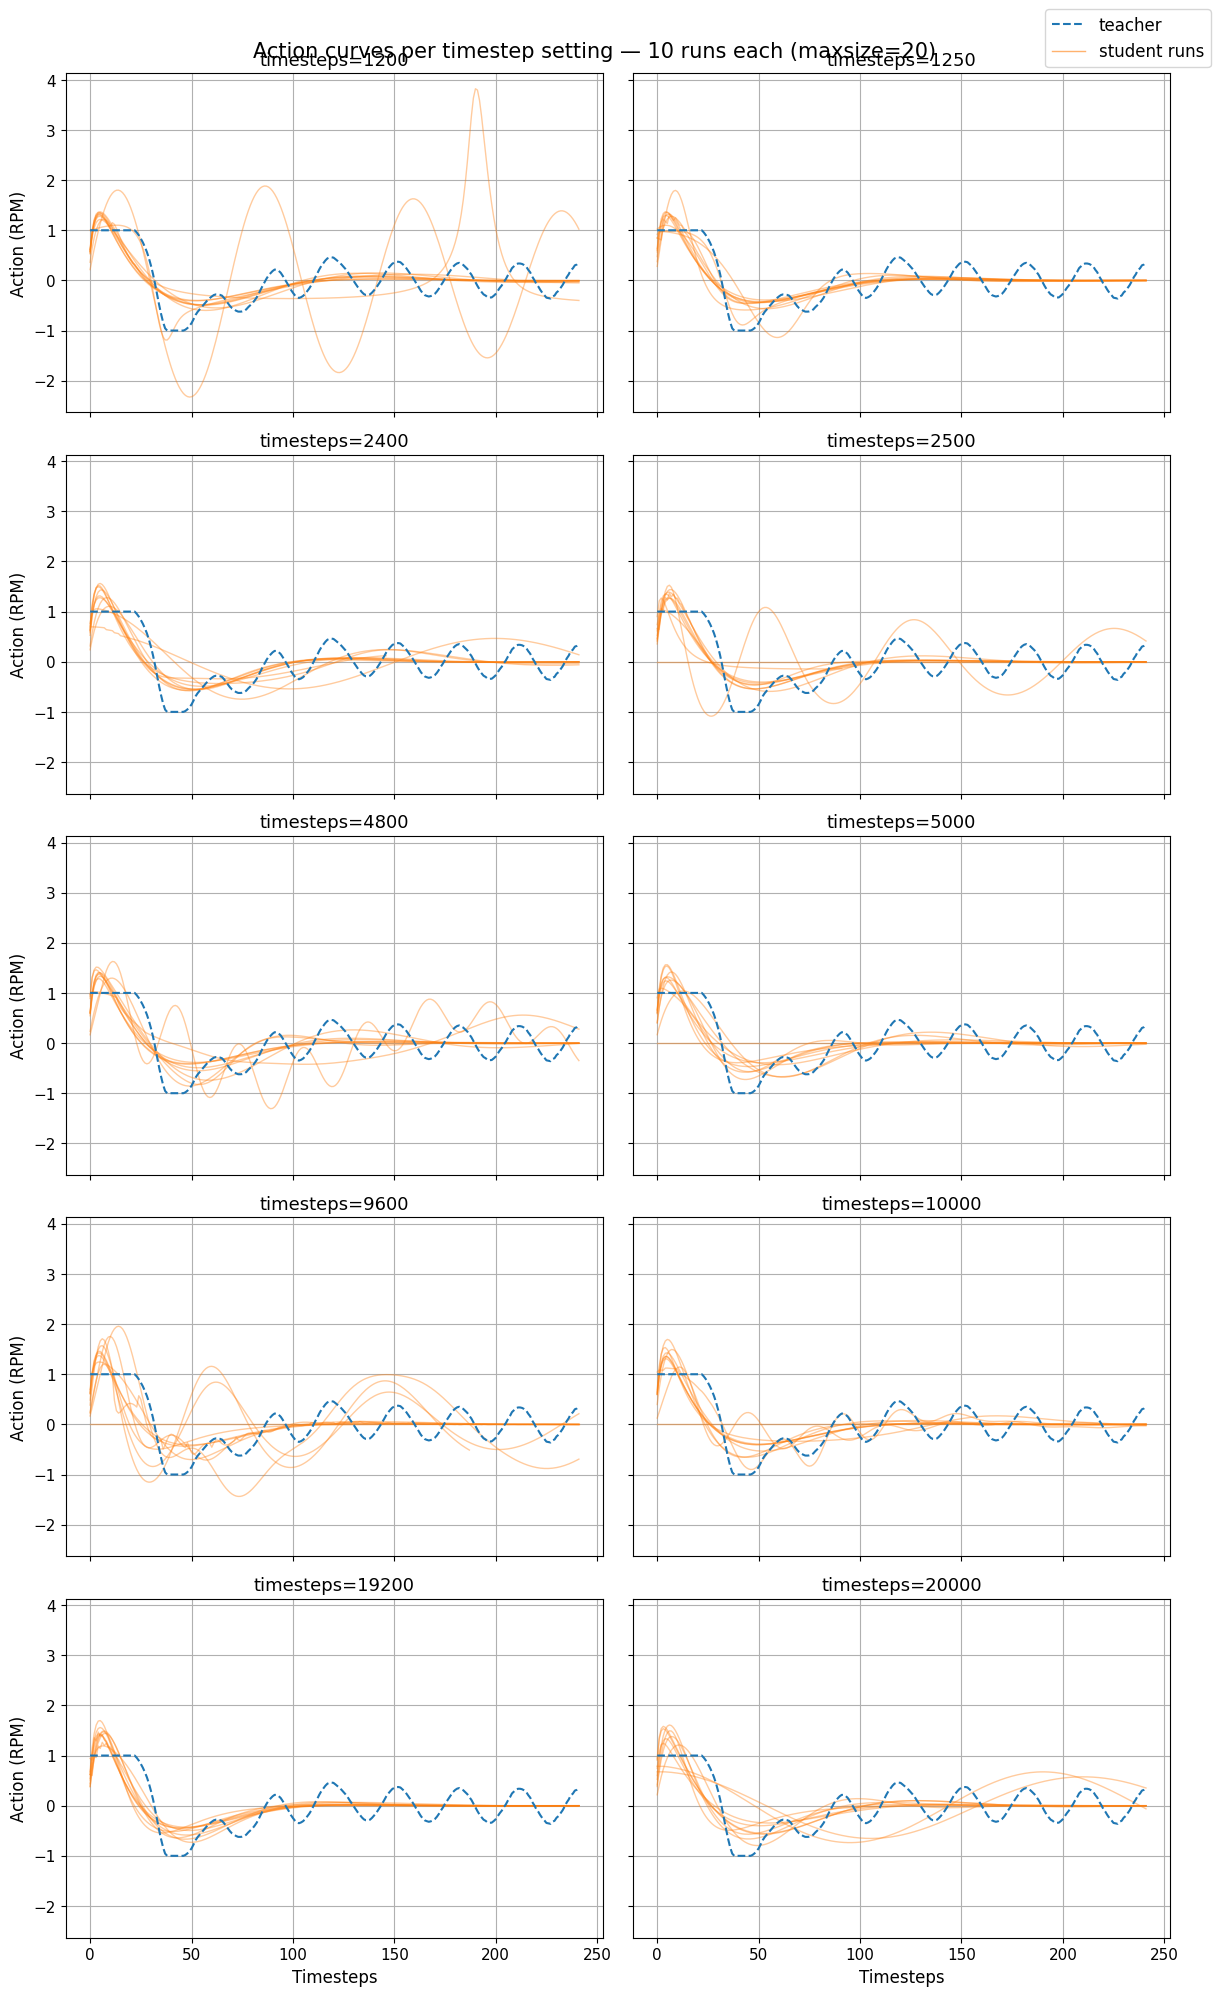

In [11]:
import math

# Define groups with display labels
groups = {
    "timesteps=1200":  student_paths_1200,
    "timesteps=1250":  student_paths_1250,
    "timesteps=2400":  student_paths_2400,
    "timesteps=2500":  student_paths_2500,
    "timesteps=4800":  student_paths_4800,
    "timesteps=5000":  student_paths_5000,
    "timesteps=9600":  student_paths_9600,
    "timesteps=10000": student_paths_10000,
    "timesteps=19200": student_paths_19200,
    "timesteps=20000": student_paths_20000,
}

n_cols = 2
n_rows = math.ceil(len(groups) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows),
                         sharey=True, sharex=True)
axes = axes.flatten()

for ax_idx, (group_label, group_paths) in enumerate(groups.items()):
    ax = axes[ax_idx]

    # Teacher
    ax.plot(teacher_actions, color="tab:blue", linestyle="--",
            linewidth=1.5, label="teacher", zorder=5)

    # All runs in this group
    for run_name in group_paths:
        if run_name not in all_results:
            continue
        ax.plot(all_results[run_name]["actions"],
                color="tab:orange", alpha=0.4, linewidth=1)

    ax.set_title(group_label, fontsize=13)
    ax.grid(True)
    ax.tick_params(axis='both', labelsize=11)

    if ax_idx % n_cols == 0:
        ax.set_ylabel("Action (RPM)", fontsize=12)
    if ax_idx >= len(groups) - n_cols:
        ax.set_xlabel("Timesteps", fontsize=12)

# Hide unused subplots
for ax_idx in range(len(groups), len(axes)):
    axes[ax_idx].set_visible(False)

# Single legend
handles = [
    plt.Line2D([0], [0], color="tab:blue", linestyle="--", linewidth=1.5, label="teacher"),
    plt.Line2D([0], [0], color="tab:orange", alpha=0.6, linewidth=1, label="student runs"),
]
fig.legend(handles=handles, loc="upper right", bbox_to_anchor=(1.02, 1), fontsize=12)

plt.suptitle("Action curves per timestep setting — 10 runs each (maxsize=20)", fontsize=15)
plt.tight_layout()
plt.savefig("actions_by_timestep_group.png", dpi=150, bbox_inches="tight")
plt.show()



── timesteps=1200 ──
Policy loaded
[INFO] BaseAviary.__init__() loaded parameters from the drone's .urdf:
[INFO] m 0.027000, L 0.039700,
[INFO] ixx 0.000014, iyy 0.000014, izz 0.000022,
[INFO] kf 3.160000e-10, km 7.940000e-12,
[INFO] t2w 2.250000, max_speed_kmh 30.000000,
[INFO] gnd_eff_coeff 11.368590, prop_radius 0.023135,
[INFO] drag_xy_coeff 0.000001, drag_z_coeff 0.000001,
[INFO] dw_coeff_1 2267.180000, dw_coeff_2 0.160000, dw_coeff_3 -0.110000
[INFO] BaseAviary.__init__() loaded parameters from the drone's .urdf:
[INFO] m 0.027000, L 0.039700,
[INFO] ixx 0.000014, iyy 0.000014, izz 0.000022,
[INFO] kf 3.160000e-10, km 7.940000e-12,
[INFO] t2w 2.250000, max_speed_kmh 30.000000,
[INFO] gnd_eff_coeff 11.368590, prop_radius 0.023135,
[INFO] drag_xy_coeff 0.000001, drag_z_coeff 0.000001,
[INFO] dw_coeff_1 2267.180000, dw_coeff_2 0.160000, dw_coeff_3 -0.110000
[INFO] BaseAviary.__init__() loaded parameters from the drone's .urdf:
[INFO] m 0.027000, L 0.039700,
[INFO] ixx 0.000014, iyy

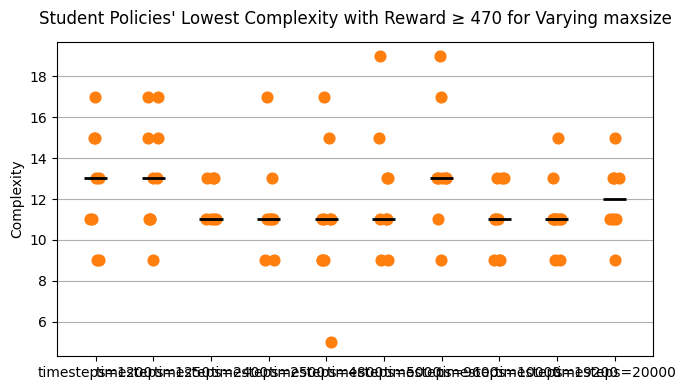

In [ ]:
from io import StringIO

THRESHOLD = 470

groups = {
    "timesteps=1200":  student_paths_1200,
    "timesteps=1250":  student_paths_1250,
    "timesteps=2400":  student_paths_2400,
    "timesteps=2500":  student_paths_2500,
    "timesteps=4800":  student_paths_4800,
    "timesteps=5000":  student_paths_5000,
    "timesteps=9600":  student_paths_9600,
    "timesteps=10000": student_paths_10000,
    "timesteps=19200": student_paths_19200,
    "timesteps=20000": student_paths_20000,
}

first_working = {label: [] for label in groups}

for group_label, paths in groups.items():
    print(f"\n── {group_label} ──")
    for run_name, policy_path in paths.items():
        base_policy = PySRPolicy.load(policy_path)
        n_expr = len(base_policy.policy_list[0].sr.equations_)

        found = None
        for idx in range(n_expr):
            stdout, stderr = sys.stdout, sys.stderr
            try:
                sys.stdout = sys.stderr = StringIO()
                student = PySRPolicy.load_policy_at_index(policy_path, idx)
            finally:
                sys.stdout, sys.stderr = stdout, stderr

            complexity = base_policy.policy_list[0].sr.equations_.iloc[idx]["complexity"]
            rewards, _, _ = collect_actions(student, seed=42)
            total = sum(rewards)

            if total >= THRESHOLD:
                found = int(complexity)
                break  # stop at first working

        first_working[group_label].append(found)
        print(f"  {run_name}: first working complexity = {found} "
              f"({'none' if found is None else ''})")

# Plot
fig, ax = plt.subplots(figsize=(7, 4))

group_labels = list(first_working.keys())
x_positions  = np.arange(len(group_labels))

for x, label in zip(x_positions, group_labels):
    values  = first_working[label]
    numeric = [v for v in values if v is not None]
    none_count = values.count(None)

    # jitter x slightly so points don't overlap
    jitter = np.random.uniform(-0.1, 0.1, size=len(numeric))
    ax.scatter(x + jitter, numeric, color="tab:orange", zorder=3,
               s=60, label="run" if x == 0 else "")

    if numeric:
        ax.hlines(np.median(numeric), x - 0.2, x + 0.2,
                  color="black", linewidth=2, zorder=4)

ax.set_xticks(x_positions)
ax.set_xticklabels(group_labels)
ax.set_ylabel("Complexity")
ax.set_title(f"Student Policies' Lowest Complexity with Reward ≥ {THRESHOLD} for Varying maxsize", y=1.03)
ax.grid(True, axis="y")
plt.tight_layout()
plt.savefig("first_working_complexity_by_maxsize.png", dpi=150)
plt.show()
